# Notebook 5 - Benchmarks, métricas y análisis final

N5 cierra el pipeline completo: compara la estrategia de momentum frente al S&P 500 (SPY), mide retorno y riesgo con las métricas obligatorias del enunciado, diagnostica el impacto operativo de fricciones reales (comisiones, no-fills, salidas proxy) y cuantifica la robustez estadística con 30 millones de carteras aleatorias vía Monte Carlo directo.

La pregunta central que N5 responde es: **¿aporta valor la estrategia después de costes y restricciones reales, o podría obtenerse un resultado equivalente eligiendo activos al azar?** La respuesta se apoya en evidencia numérica, no en intuición.

**Artefactos de entrada (producidos por N1-N4):**

| Fuente | Artefacto | Propósito |
|---|---|---|
| N1 | `n1_runtime_params.csv`, `n1_benchmark_provenance.csv` | Parámetros y benchmark |
| N2 | `n2_signals_input.parquet` | Universo elegible para Monte Carlo |
| N4 | `n4_portfolio_daily.csv`, `n4_orders_log.csv` | Equity y órdenes ejecutadas |
| N4 | `n4_cost_summary.csv`, `n4_rebalance_summary.csv`, `n4_checks.csv` | Costes y controles |

---

## 1. Configuración y funciones de medida

Se importan las librerías y se definen todas las funciones de medida de rendimiento en un único bloque. Las funciones siguen las convenciones académicas estándar: anualización con raíz de 252 para volatilidad y Sharpe, desviación muestral (`ddof=1`) y tasa libre de riesgo configurable (fijada en 2% anual como proxy prudente de activo libre de riesgo en USD para un horizonte largo, evitando el sesgo optimista de usar 0%). El Sortino usa solo la desviación de retornos negativos, y el alpha de Jensen se computa vía la formulación clásica del CAPM con beta estimada por covarianza/varianza.

In [1]:
# Librerias: numpy/pandas para calculo, matplotlib/seaborn para graficos, scipy para regresion
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Estilo visual unificado para todos los graficos de N5
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# --- Rutas de artefactos producidos por N1, N2 y N4 ---
# --- Rutas de entrada ---
N1_RUNTIME = "data/processed/n1_runtime_params.csv"
N1_BENCH = "data/processed/n1_benchmark_provenance.csv"
N2_SIGNALS = "data/processed/n2_signals_input.parquet"
N4_DAILY = "data/processed/n4_portfolio_daily.csv"
N4_ORDERS = "data/processed/n4_orders_log.csv"
N4_COSTS = "data/processed/n4_cost_summary.csv"
N4_REBAL = "data/processed/n4_rebalance_summary.csv"
N4_CHECKS = "data/processed/n4_checks.csv"

# --- Supuestos de calculo ---
# --- Supuestos ---
# 252 dias de negociacion/ano (convencion renta variable USA)
TRADING_DAYS = 252
# Tasa libre de riesgo: 2% anual, proxy prudente en USD (evita sesgo de usar 0%)
RF_ANNUAL = 0.02
# Conversion compuesta a tasa diaria: (1+rf)^(1/252) - 1
RF_DAILY = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1

# --- Parametros Monte Carlo (enunciado: >25M monos, <24h) ---
# --- Parametros Monte Carlo ---
# 30 millones de monos (excede los 25M del enunciado)
N_MONKEYS = 30_000_000
# Semilla fija para reproducibilidad total del experimento
MONKEY_SEED = 42
# Cada mono selecciona 20 activos (misma cardinalidad que la estrategia)
MONKEY_K = 20
# Coste mensual MC: se asigna al cargar fee_rate de N1
MONKEY_COST = np.nan
# Enunciado: 2 * 0.23% = 0.46% (compra + venta completa cada mes)
MONKEY_COST_EXPECTED = 0.0046
# Tamano de lote para procesamiento en bloques (control de memoria RAM)
MONKEY_BATCH = 300_000
# Submuestra para graficos (evita saturar visualizacion con 30M puntos)
MONKEY_PLOT_N = 3_000_000


# Patron fail-fast: detiene ejecucion si se viola una precondicion
def fail_if(condition, message):
    if condition:
        raise ValueError(message)


# Convierte columnas con representacion mixta (True/1/yes/y) a booleano
def as_bool(series):
    return series.astype(str).str.strip().str.lower().isin(
        {"true", "1", "yes", "y"})


# --- Funciones de medida de rendimiento ---
def cagr(ret, days=252):
    # Todas usan ddof=1 (estimador muestral insesgado) y anualizacion con sqrt(252)
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
        # Producto acumulado de (1+r_i) a lo largo de toda la serie
    total = float((1 + ret).prod())
    years = len(ret) / days
    return total ** (1 / years) - 1 if years > 0 else np.nan


# Volatilidad anualizada = std_diaria(ddof=1) * sqrt(252)
def ann_vol(ret, days=252):
    return float(ret.dropna().std(ddof=1) * np.sqrt(days))


# Sharpe = sqrt(252) * mean(r-rf) / std(r-rf, ddof=1)
def sharpe(ret, rf=RF_DAILY, days=252):
    x = ret.dropna() - rf
    den = x.std(ddof=1)
    return float(np.sqrt(days) * x.mean() / den) if den > 0 else np.nan


# Sortino: como Sharpe pero penaliza solo volatilidad bajista
def sortino(ret, rf=RF_DAILY, days=252):
    x = ret.dropna() - rf
        # Desviacion solo de retornos negativos (riesgo a la baja)
    down = x[x < 0].std(ddof=1)
    return float(np.sqrt(days) * x.mean() / down) if down > 0 else np.nan


# Max drawdown = caida maxima desde pico historico de wealth
def max_dd(ret):
        # Curva de wealth acumulada: (1+r1)*(1+r2)*...
    w = (1 + ret.dropna()).cumprod()
    return float((w / w.cummax() - 1).min()) if len(w) > 0 else np.nan


# Beta CAPM = cov(strat,bench)/var(bench); Alpha Jensen anualizado compuesto
def beta_alpha(strat, bench, rf=RF_DAILY, days=252):
    x = pd.concat([strat, bench], axis=1).dropna()
    x.columns = ["s", "b"]
    if len(x) < 2:
        return np.nan, np.nan
        # Excesos sobre tasa libre de riesgo diaria
    es, eb = x["s"] - rf, x["b"] - rf
    var_b = eb.var(ddof=1)
    if var_b <= 0:
        return np.nan, np.nan
        # Beta = cov(excess_s, excess_b) / var(excess_b)
    b = es.cov(eb) / var_b
        # Alpha: (1 + alpha_diario)^252 - 1 (anualizacion compuesta)
    a = (1 + es.mean() - b * eb.mean()) ** days - 1
    return float(b), float(a)


# Muestreo sin reemplazo: k activos distintos por fila (rejection sampling)
def sample_no_replace(rng, n_rows, n_assets, k):
    # Eficiente para k << n_assets (20 de ~500 => probabilidad colision < 1%)
    # Muestreo sin reemplazo por fila usando reintento solo en filas con
    # colisiones.
    fail_if(k > n_assets, f"k={k} > n_assets={n_assets}")
    idx = rng.integers(0, n_assets, size=(n_rows, k), dtype=np.int32)
    if k <= 1:
        return idx
    while True:
                # Detecta filas con duplicados y solo reintenta esas filas
        bad = (np.diff(np.sort(idx, axis=1), axis=1) == 0).any(axis=1)
        n_bad = int(bad.sum())
        if n_bad == 0:
            break
        idx[bad] = rng.integers(0, n_assets, size=(n_bad, k), dtype=np.int32)
    return idx


print("Configuracion lista.")
print(
    f"  Monte Carlo: {
        N_MONKEYS:,} monos, k={MONKEY_K}, coste=2*fee_rate (runtime)")
print(f"  Rf annual:   {RF_ANNUAL:.2%}, Trading days: {TRADING_DAYS}")


Configuracion lista.
  Monte Carlo: 30,000,000 monos, k=20, coste=2*fee_rate (runtime)
  Rf annual:   2.00%, Trading days: 252


In [2]:
# --- Cache Monte Carlo directo ---
# Si existe ejecucion previa valida, se carga sin recalcular (ahorra horas)
FORCE_RECOMPUTE_MONKEYS = False  # True => recalcula y sobrescribe

# Rutas de cache para wealth final, resumen, cuantiles y submuestra
MC_DIRECT_WEALTH_NPY = "data/processed/n5_mc_direct_wealth.npy"
MC_DIRECT_SUMMARY_CSV = "data/processed/n5_mc_direct_summary.csv"
MC_DIRECT_QUANT_CSV = "data/processed/n5_mc_direct_quantiles.csv"
MC_DIRECT_SAMPLE_CSV = "data/processed/n5_mc_direct_sample.csv"


---

## 2. Carga de artefactos y ventana común

Se cargan los artefactos de N1 a N4 y el benchmark (SPY). La intersección temporal entre la serie diaria del portfolio y la serie del SPY define la **ventana común** sobre la que se calculan todas las métricas comparativas. Esto garantiza que estrategia y benchmark se midan en exactamente los mismos días, eliminando cualquier sesgo de calendario.

In [3]:
# ================================================================
# Carga
# Carga de todos los artefactos producidos por N1, N2 y N4
runtime_df = pd.read_csv(N1_RUNTIME)
runtime_params = dict(zip(runtime_df["parameter"], runtime_df["value"]))
benchmark_prov = pd.read_csv(N1_BENCH)
# Universo elegible con retornos forward observados (para Monte Carlo)
signals_input = pd.read_parquet(N2_SIGNALS)
# Serie diaria de equity, cash y numero de posiciones del portfolio
portfolio_daily = pd.read_csv(
    N4_DAILY,
    parse_dates=["date"]).sort_values("date").reset_index(
        drop=True)
# Log completo de ordenes: ejecutadas, no_fill_cash, forzosas
orders = pd.read_csv(N4_ORDERS, parse_dates=["date", "proxy_price_date"])
# Resumen consolidado de costes y rentabilidad
cost_summary = pd.read_csv(N4_COSTS)
# Resumen por fecha de rebalanceo (equity, cash, posiciones, incidencias)
rebalance_summary = pd.read_csv(N4_REBAL, parse_dates=["date"])
# Checks de integridad heredados de N4
n4_checks = pd.read_csv(N4_CHECKS)

# Normalizacion de retornos: fallback si N4 no exporto las columnas
# Normalizacion de retornos de N4
if "return_vs_initial_capital" not in cost_summary.columns:
    cost_summary["return_vs_initial_capital"] = (
        cost_summary["final_equity"] / cost_summary["initial_capital"] - 1.0
    )
if "return_from_first_valuation" not in cost_summary.columns:
    if "equity_day1" in cost_summary.columns:
        equity_day1 = pd.to_numeric(
            cost_summary["equity_day1"],
            errors="coerce")
        cost_summary["return_from_first_valuation"] = np.where(
            equity_day1 > 0,
            cost_summary["final_equity"] / equity_day1 - 1.0,
            np.nan,
        )
    elif "total_return" in cost_summary.columns:
        cost_summary["return_from_first_valuation"] = cost_summary["total_return"]
    else:
        cost_summary["return_from_first_valuation"] = np.nan

# ================================================================
# Validacion de checks criticos heredados de N4
# Validacion de checks criticos heredados de N4
required_n4_cols = {"check", "passed", "critical"}
# Si algun check critico fallo, N5 no debe continuar
fail_if(not required_n4_cols.issubset(n4_checks.columns),
        "n4_checks invalido: faltan columnas check/passed/critical")
n4_checks_eval = n4_checks.copy()
n4_checks_eval["critical_bool"] = as_bool(n4_checks_eval["critical"])
n4_checks_eval["passed_bool"] = as_bool(n4_checks_eval["passed"])
n4_critical_failed = n4_checks_eval.loc[
    n4_checks_eval["critical_bool"] & ~n4_checks_eval["passed_bool"],
    ["check", "details"],
].copy()
fail_if(
    len(n4_critical_failed) > 0,
    "N4 checks criticos fallidos:\n" +
    n4_critical_failed.to_string(
        index=False),
)

# ================================================================
# Benchmark
# Carga del benchmark SPY y calculo del coste MC
bench_path = runtime_params.get(
    "benchmark_parquet",
    "data/raw/spy_yfinance.parquet")
bench_price_col = runtime_params.get(
    "benchmark_return_price_field", "close_adj")
spy = pd.read_parquet(bench_path)
spy["date"] = pd.to_datetime(spy["date"])
spy = spy.sort_values("date").reset_index(drop=True)

# Coste mensual MC = 2 * fee_rate (enunciado: turnover completo cada mes)
fee_rate = float(runtime_params.get("transaction_fee_rate", 0.0023))
fee_min = float(runtime_params.get("min_fee_per_order", 23.0))
MONKEY_COST = float(2.0 * fee_rate)

# ================================================================
# Validaciones minimas
# Validacion de columnas requeridas en cada artefacto
for name, cols, df in [
    ("portfolio_daily", {
        "date", "equity", "daily_return", "cash", "n_positions"}, portfolio_daily), ("orders", {
            "date", "status", "reason", "fee", "notional", "side"}, orders), ("signals_input", {
                "rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"}, signals_input), ]:
    fail_if(not cols.issubset(df.columns), f"{name}: faltan columnas")
fail_if(not {"date", bench_price_col}.issubset(spy.columns),
        f"Benchmark invalido: falta columna '{bench_price_col}'")

# ================================================================
# Ventana comun
# Ventana comun estrategia-SPY: interseccion de fechas
strat = portfolio_daily.set_index("date")[
    # Solo se comparan dias donde ambas series tienen dato
    ["daily_return", "equity", "cash", "n_positions"]]
spy_ret = spy.set_index("date")[[bench_price_col]].rename(
    columns={bench_price_col: "bench_price"})
# Retorno diario simple del benchmark: (P_t / P_{t-1}) - 1
spy_ret["spy_return"] = spy_ret["bench_price"].pct_change()
common = strat.index.intersection(spy_ret.index)
returns_daily = pd.DataFrame({
    "strategy": strat.loc[common, "daily_return"],
    "spy": spy_ret.loc[common, "spy_return"],
}).dropna()
fail_if(len(returns_daily) == 0, "No hay interseccion estrategia-SPY")

# Agregaciones temporales: retornos compuestos mensuales, trimestrales, anuales
# Agregaciones temporales
# Composicion: prod(1+r_diario) - 1 por cada periodo
monthly_returns = (1 + returns_daily).resample("ME").prod() - 1
quarterly_returns = (1 + returns_daily).resample("QE").prod() - 1
annual_returns = (1 + returns_daily).resample("YE").prod() - 1

backtest_end_data = pd.to_datetime(
    runtime_params.get(
        "backtest_end_data",
        None),
    errors="coerce")
benchmark_last_date = spy["date"].max()

print(
    f"Checks criticos N4: {int(n4_checks_eval['critical_bool'].sum())} revisados, 0 fallidos")
print(
    "Coste MC derivado: "
    f"2*fee_rate = {MONKEY_COST:.4f} "
    f"(esperado enunciado~{MONKEY_COST_EXPECTED:.4f})"
)
print(f"Benchmark: columna de retorno = '{bench_price_col}'")
print(
    f"Ventana comun: {
        returns_daily.index.min().date()} -> {
            returns_daily.index.max().date()}")
print(f"  Diarias:      {len(returns_daily):,}")
print(f"  Mensuales:    {len(monthly_returns)}")
print(f"  Trimestrales: {len(quarterly_returns)}")
print(f"  Anuales:      {len(annual_returns)}")
if pd.notna(backtest_end_data) and pd.notna(benchmark_last_date):
    print(
        "Nota de periodo: backtest operativo hasta "
        f"{backtest_end_data.date()} (limite PIT de universo/precios), "
        f"aunque SPY dispone de datos hasta {benchmark_last_date.date()}."
    )


Checks criticos N4: 36 revisados, 0 fallidos
Coste MC derivado: 2*fee_rate = 0.0046 (esperado enunciado~0.0046)
Benchmark: columna de retorno = 'close_adj'
Ventana comun: 2015-01-30 -> 2026-01-30
  Diarias:      2,767
  Mensuales:    133
  Trimestrales: 45
  Anuales:      12
Nota de periodo: backtest operativo hasta 2026-01-30 (limite PIT de universo/precios), aunque SPY dispone de datos hasta 2026-02-27.


---

## 3. Métricas obligatorias

La tabla consolida las siete métricas exigidas por el enunciado: CAGR, volatilidad anualizada, Sharpe, Sortino, máximo drawdown, beta y alpha de Jensen. Se presentan para estrategia y SPY en la misma tabla para facilitar la comparación directa. Los supuestos de cálculo (tasa libre de riesgo, días de anualización, ventana temporal) se explicitan debajo.

In [4]:
# Beta y alpha Jensen via formulacion clasica del CAPM
b, a = beta_alpha(
    returns_daily["strategy"],
    returns_daily["spy"],
    RF_DAILY, TRADING_DAYS)

# ================================================================
# convetir a porcentaje el cagr y volatilidad anualizada y max drawdown
# Tabla con las 7 metricas exigidas por el enunciado
# para que sea mas legible en la tabla de metricas
# Calculadas sobre la ventana comun diaria estrategia vs SPY

# CAGR, Volatilidad, Sharpe, Sortino, Max DD, Beta, Alpha Jensen
metrics = pd.DataFrame(
    [
                # CAGR = tasa de crecimiento anualizada compuesta
        {
            "metric": "CAGR",
            "strategy": cagr(returns_daily["strategy"]),
            "spy": cagr(returns_daily["spy"]),
        },
                # Volatilidad anualizada = std(ddof=1) * sqrt(252)
        {
            "metric": "Volatility (annualized)",
            "strategy": ann_vol(returns_daily["strategy"]),
            "spy": ann_vol(returns_daily["spy"]),
        },
                # Sharpe con rf = 2% anual
        {
            "metric": "Sharpe",
            "strategy": sharpe(returns_daily["strategy"], RF_DAILY),
            "spy": sharpe(returns_daily["spy"], RF_DAILY),
        },
                # Sortino: penaliza solo la volatilidad bajista
        {
            "metric": "Sortino",
            "strategy": sortino(returns_daily["strategy"], RF_DAILY),
            "spy": sortino(returns_daily["spy"], RF_DAILY),
        },
                # Max drawdown: caida maxima pico-a-valle
        {
            "metric": "Max Drawdown",
            "strategy": max_dd(returns_daily["strategy"]),
            "spy": max_dd(returns_daily["spy"]),
        },
                # Beta: sensibilidad al mercado (1.0 = neutral)
        {
            "metric": "Beta (vs SPY)",
            "strategy": b,
            "spy": 1.0,
        },
                # Alpha Jensen: exceso/defecto de retorno ajustado por riesgo CAPM
        {
            "metric": "Alpha Jensen (annualized)",
            "strategy": a,
            "spy": 0.0,
        },
    ]
)

# Formato: porcentaje para CAGR/Vol/DD/Alpha, 3 decimales para ratios
pct_metrics = {
    "CAGR",
    "Volatility (annualized)",
    "Max Drawdown",
    "Alpha Jensen (annualized)"}

# Aplicar formato condicional por tipo de metrica
metrics_show = metrics.copy()
for col in ["strategy", "spy"]:
    metrics_show[col] = metrics_show.apply(
        lambda r: f"{
            r[col]:.2%}" if r["metric"] in pct_metrics else f"{
            r[col]:.3f}", axis=1, )

# Mostrar tabla comparativa y supuestos de calculo
display(metrics_show)

print(f"\nSupuestos:")
print(
    f"  Ventana:  {
        returns_daily.index.min().date()} -> {
            returns_daily.index.max().date()}")
print(f"  Rf:       {RF_ANNUAL:.2%} annual ({RF_DAILY:.6%} daily)")
print(f"  Dias/ano: {TRADING_DAYS}")


,metric,strategy,spy
0,CAGR,12.41%,13.78%
1,Volatility (annualized),23.82%,17.75%
2,Sharpe,0.528,0.705
3,Sortino,0.679,0.857
4,Max Drawdown,-40.26%,-33.72%
5,Beta (vs SPY),1.045,1.000
6,Alpha Jensen (annualized),-0.50%,0.00%



Supuestos:
  Ventana:  2015-01-30 -> 2026-01-30
  Rf:       2.00% annual (0.007858% daily)
  Dias/ano: 252


---

## 4. Rentabilidad acumulada

La curva acumulada base 100 permite ver la trayectoria relativa entre estrategia y benchmark a lo largo de todo el período. El sombreado verde indica fases de outperformance y el rojo fases de underperformance. Lo relevante no es solo el punto final sino la estabilidad del diferencial: una estrategia que supera al benchmark de forma sostenida es más defendible que una que concentra toda su ventaja en un único período.

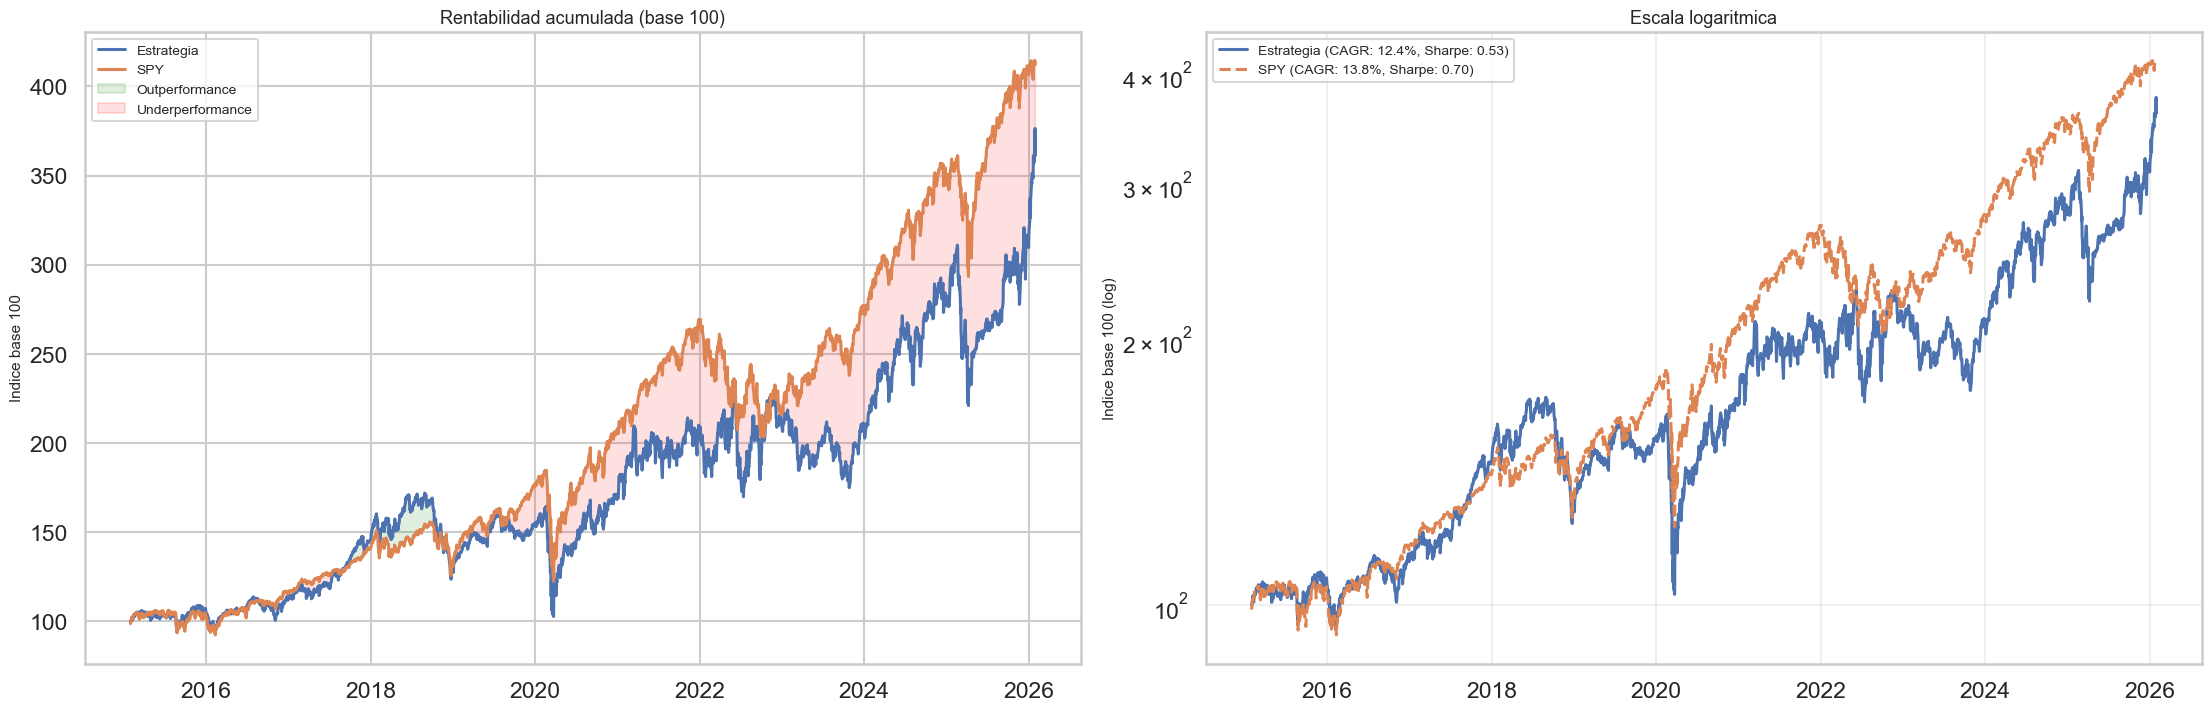

In [5]:
# Metricas de resumen para anotaciones en leyenda del grafico
cagr_s = float(metrics.loc[metrics["metric"] == "CAGR", "strategy"].iloc[0])
cagr_b = float(metrics.loc[metrics["metric"] == "CAGR", "spy"].iloc[0])
sharpe_s = float(metrics.loc[metrics["metric"] ==
                 "Sharpe", "strategy"].iloc[0])
sharpe_b = float(metrics.loc[metrics["metric"] == "Sharpe", "spy"].iloc[0])

# Indice acumulado base 100: (1+r1)*(1+r2)*...*100
cum = (1 + returns_daily[["strategy", "spy"]]).cumprod() * 100
# Diferencial para determinar zonas de over/underperformance
spread = cum["strategy"] - cum["spy"]

# Dos paneles: escala lineal (izquierda) y logaritmica (derecha)
fig, axes = plt.subplots(1, 2, figsize=(22, 7), constrained_layout=True)

# Panel izquierdo: lineal con sombreado de over/underperformance
# Panel 1: escala lineal con sombreado
# Curvas principales: estrategia y SPY sobre la misma escala
axes[0].plot(cum.index, cum["strategy"], label="Estrategia", linewidth=2.2)
axes[0].plot(cum.index, cum["spy"], label="SPY", linewidth=2.2)
# Verde = estrategia por encima de SPY
axes[0].fill_between(
    cum.index,
    cum["strategy"],
    cum["spy"],
    where=(
        spread >= 0).to_numpy(),
    color="green",
    alpha=0.12,
    label="Outperformance")
# Rojo = estrategia por debajo de SPY
axes[0].fill_between(
    cum.index,
    cum["strategy"],
    cum["spy"],
    where=(
        spread < 0).to_numpy(),
    color="red",
    alpha=0.12,
    label="Underperformance")
# Titulo y leyenda del panel lineal
axes[0].set_title("Rentabilidad acumulada (base 100)")
axes[0].set_ylabel("Indice base 100")
axes[0].legend(loc="upper left", fontsize=10)

# Panel derecho: escala logaritmica (mejor para crecimiento compuesto)
# Panel 2: escala logaritmica con metricas en leyenda
axes[1].plot(
    cum.index,
    cum["strategy"],
    label=f"Estrategia (CAGR: {
        cagr_s:.1%}, Sharpe: {
            sharpe_s:.2f})",
    linewidth=2.2)
axes[1].plot(
    cum.index,
    cum["spy"],
    label=f"SPY (CAGR: {
        cagr_b:.1%}, Sharpe: {
            sharpe_b:.2f})",
    linewidth=2.2,
    linestyle="--")
# Log permite comparar tasas de crecimiento relativo a largo plazo
axes[1].set_yscale("log")
axes[1].set_title("Escala logaritmica")
axes[1].set_ylabel("Indice base 100 (log)")
axes[1].legend(loc="upper left", fontsize=10)
axes[1].grid(True, alpha=0.3)

# Renderizar ambos paneles
plt.show()


---

## 5. Distribuciones de retornos

El histograma mensual compara el perfil de dispersiones entre estrategia y SPY: colas más gruesas indican meses con movimientos extremos más frecuentes. El heatmap anual-mensual permite identificar visualmente si la estrategia tiene patrones estacionales o concentra su rendimiento en períodos específicos.

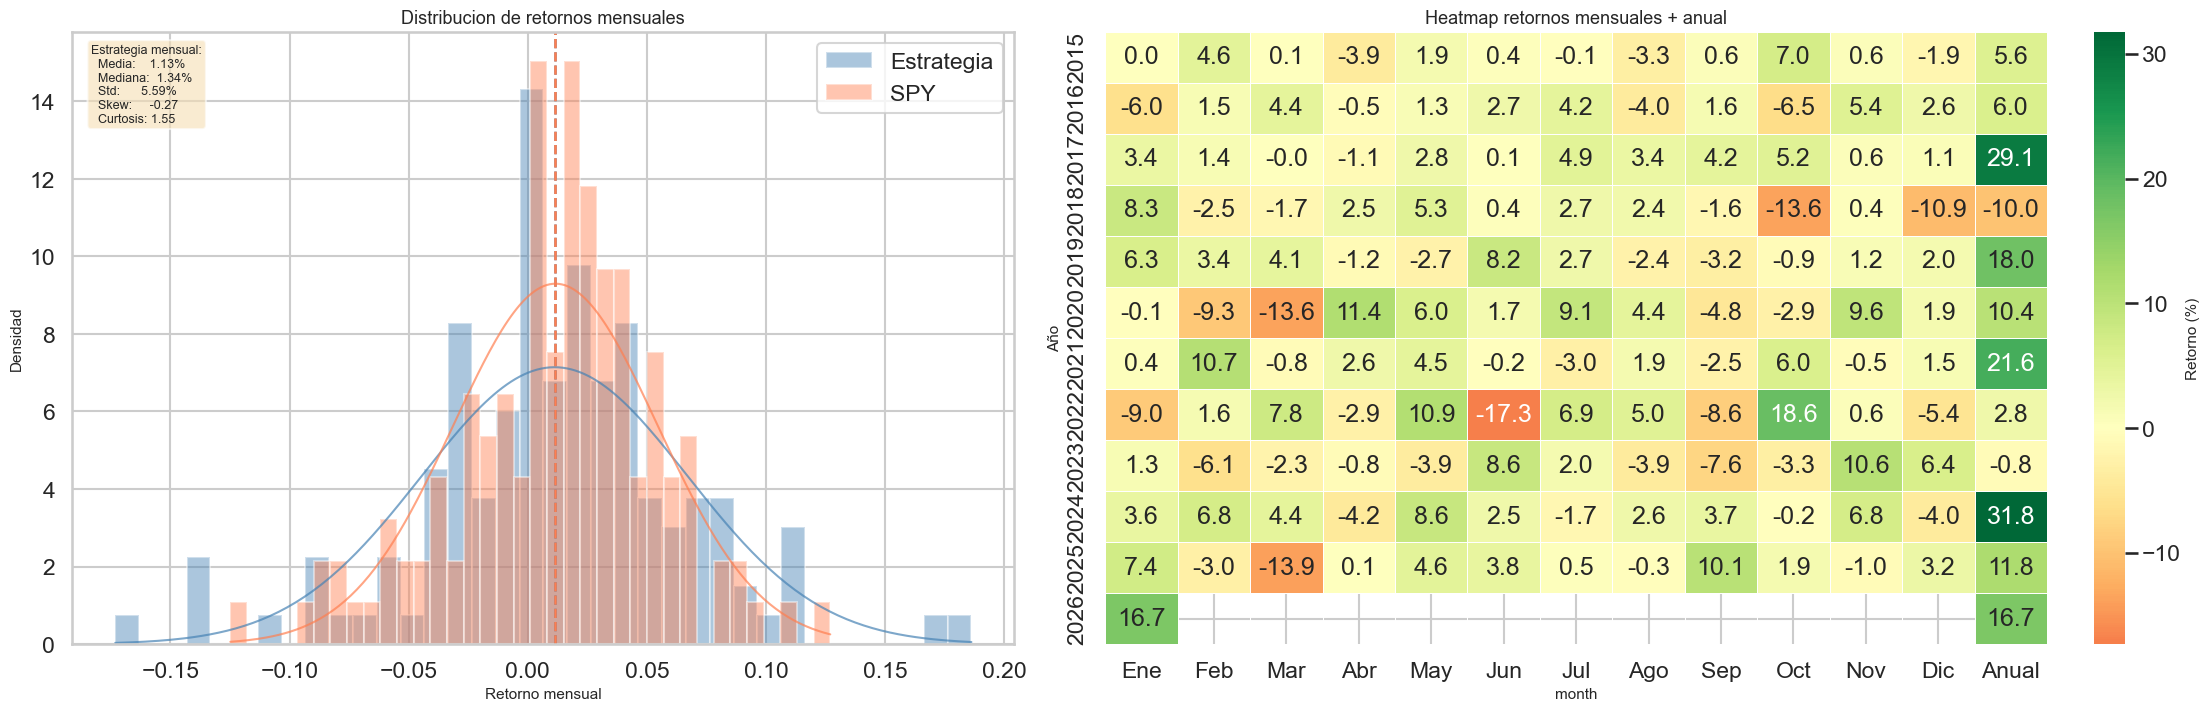

In [6]:
# Dos paneles: histograma de retornos mensuales (izq) y heatmap ano x mes (der)
fig, axes = plt.subplots(1, 2, figsize=(22, 7), constrained_layout=True)

# Superponer histogramas de estrategia y SPY para comparar dispersion
# Panel 1: histograma mensual con curva normal
for col, color, label in [
    ("strategy", "steelblue", "Estrategia"),
        ("spy", "coral", "SPY")]:
    ret = monthly_returns[col].dropna()
        # Histograma de densidad con borde blanco para legibilidad
    axes[0].hist(
        ret,
        bins=36,
        density=True,
        alpha=0.45,
        color=color,
        edgecolor="white",
        label=label)
        # Media mensual como linea vertical de referencia
    axes[0].axvline(ret.mean(), color=color, linestyle="--", linewidth=1.8)
        # Curva gaussiana teorica superpuesta (detectar desviaciones de normalidad)
    # Curva normal superpuesta
    x = np.linspace(ret.min(), ret.max(), 200)
    axes[0].plot(
        x,
        stats.norm.pdf(
            x,
            ret.mean(),
            ret.std()),
        color=color,
        linewidth=1.5,
        alpha=0.7)

# Estadisticos descriptivos: media, mediana, std, skewness, curtosis
# Textbox de stats
# Skew > 0 implica cola derecha mas larga; curtosis > 0 implica colas gruesas
s_ret = monthly_returns["strategy"].dropna()
box_text = (f"Estrategia mensual:\n"
            f"  Media:    {s_ret.mean():.2%}\n"
            f"  Mediana:  {s_ret.median():.2%}\n"
            f"  Std:      {s_ret.std():.2%}\n"
            f"  Skew:     {s_ret.skew():.2f}\n"
            f"  Curtosis: {s_ret.kurtosis():.2f}")
# Textbox con estadisticos descriptivos en esquina superior izquierda
axes[0].text(
    0.02,
    0.98,
    box_text,
    transform=axes[0].transAxes,
    fontsize=9,
    va="top",
    bbox=dict(
        boxstyle="round",
        facecolor="wheat",
        alpha=0.6))
# Titulo y ejes del histograma
axes[0].set_title("Distribucion de retornos mensuales")
axes[0].set_xlabel("Retorno mensual")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Panel 2: heatmap ano x mes con columna de retorno anual compuesto
# Panel 2: heatmap con columna anual
heat = monthly_returns["strategy"].copy() * 100
heat_df = pd.DataFrame(
    {"year": heat.index.year, "month": heat.index.month, "value": heat.values})
# Pivotar a formato matricial: filas = anos, columnas = meses
heat_pivot = heat_df.pivot(
    index="year",
    columns="month",
    values="value").reindex(
        columns=range(
            1,
            13))

# Insertar columna anual (retorno compuesto del ano completo)
# Columna anual
annual_by_year = annual_returns["strategy"].copy() * 100
for yr in heat_pivot.index:
    mask = annual_by_year.index.year == yr
    heat_pivot.loc[yr, "Anual"] = float(
        annual_by_year[mask].values[0]) if mask.any() else np.nan

# Etiquetas abreviadas en espanol para el eje X
months = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
    "Anual"]
# Colormap divergente centrado en 0: verde = positivo, rojo = negativo
sns.heatmap(heat_pivot, cmap="RdYlGn", center=0, annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "Retorno (%)"}, ax=axes[1])
# Titulo y ejes del heatmap
axes[1].set_title("Heatmap retornos mensuales + anual")
axes[1].set_xticklabels(months, rotation=0)
axes[1].set_ylabel("Año")
plt.show()


---

## 6. Scatter anual y trimestral

Los scatter plots comparan retornos periódicos de la estrategia frente al SPY. La línea de regresión captura la sensibilidad (beta), el $R^2$ mide la proporción de varianza explicada por el benchmark, y la línea de 45 grados indica retorno idéntico. Puntos por encima de la diagonal representan períodos de outperformance. Se incluyen ambas granularidades porque el scatter anual puede engañar con pocas observaciones; el trimestral aporta más datos pero con mayor ruido.

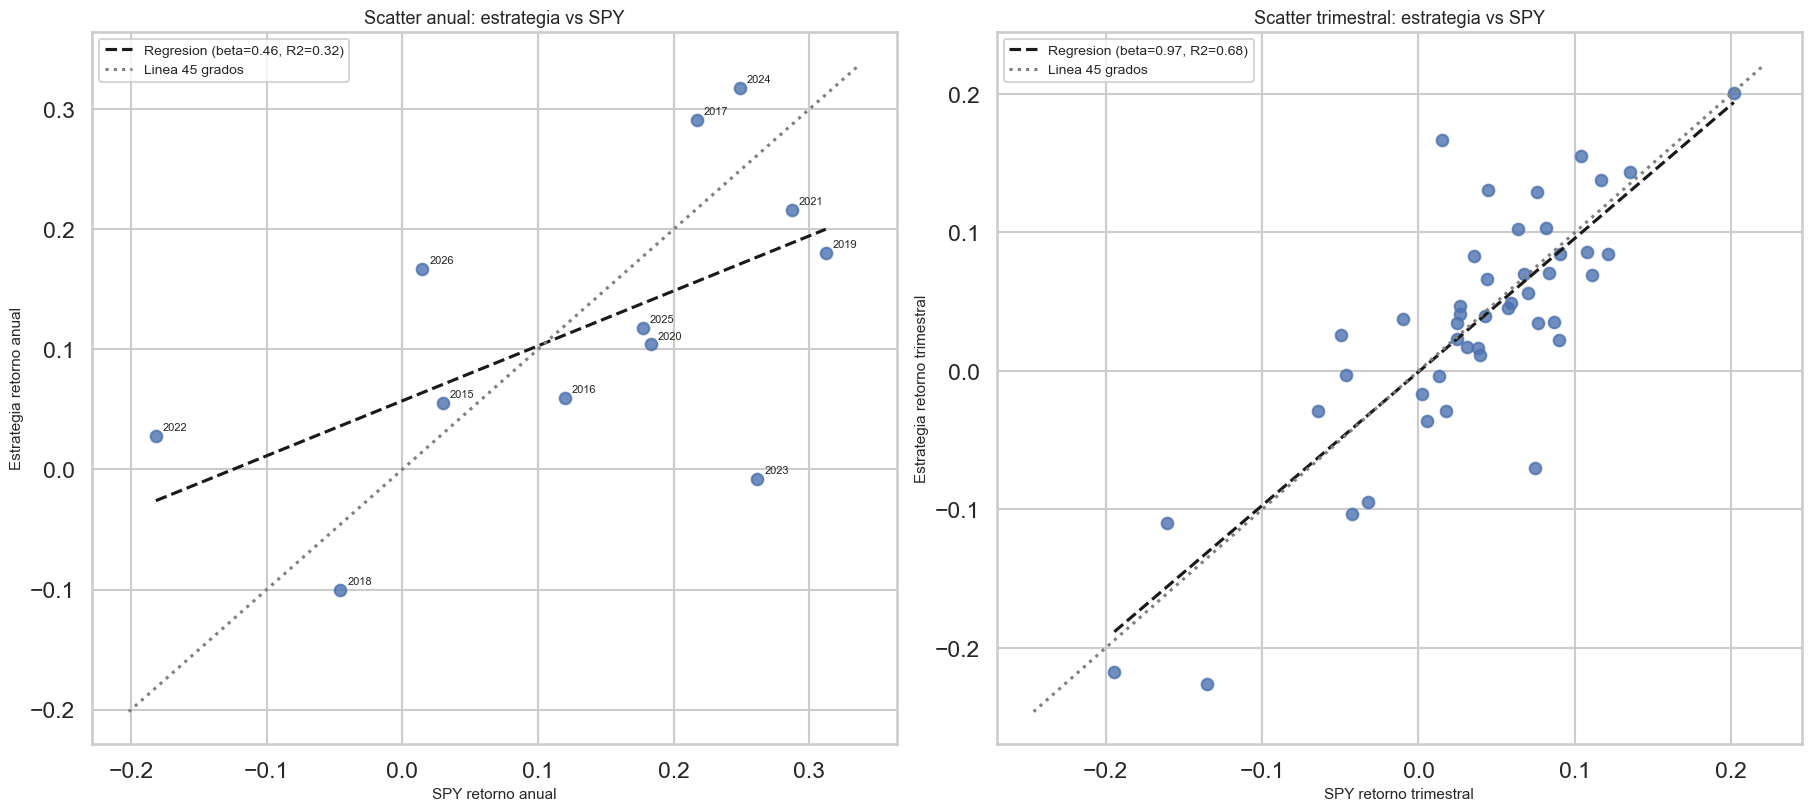

In [7]:
# Scatter de recurrencia: retornos periodicos estrategia vs SPY
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)
# Incluye regresion lineal (pendiente = beta del periodo) y diagonal 45 grados

for ax, ret_df, freq in [
    (axes[0], annual_returns.dropna(), "anual"),
    (axes[1], quarterly_returns.dropna(), "trimestral"),
]:
    x = ret_df["spy"].to_numpy()
    y = ret_df["strategy"].to_numpy()
        # Regresion lineal: pendiente = beta, R2 = varianza explicada por SPY
    reg = stats.linregress(x, y)
    r2 = reg.rvalue ** 2

    ax.scatter(x, y, s=70, alpha=0.8)
    xs = np.sort(x)
        # Linea de regresion con beta y R2 en leyenda
    ax.plot(xs, reg.intercept + reg.slope * xs, "k--",
            label=f"Regresion (beta={reg.slope:.2f}, R2={r2:.2f})")
        # Diagonal 45 grados: puntos por encima = outperformance
    lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
    ax.plot(lims, lims, ":", color="gray", label="Linea 45 grados")
    ax.set_title(f"Scatter {freq}: estrategia vs SPY")
    ax.set_xlabel(f"SPY retorno {freq}")
    ax.set_ylabel(f"Estrategia retorno {freq}")
    ax.legend(fontsize=10)

        # Anotar con el ano cada punto del scatter anual
    if freq == "anual":
        ret_df = ret_df.copy()
        ret_df["year"] = ret_df.index.year
        for _, row in ret_df.iterrows():
            ax.annotate(str(int(row["year"])), (row["spy"], row["strategy"]),
                        textcoords="offset points", xytext=(5, 4), fontsize=8)

plt.show()


---

## 7. Persistencia de regímenes

La matriz de transición mide la probabilidad de que un mes positivo sea seguido por otro positivo (o negativo), y viceversa. Si la probabilidad en la diagonal es alta, existe inercia de régimen. La distribución de rachas complementa esta visión mostrando cuántos meses consecutivos se mantiene el signo: rachas largas positivas sugieren momentum sostenido; rachas negativas largas indican períodos de estrés prolongado.

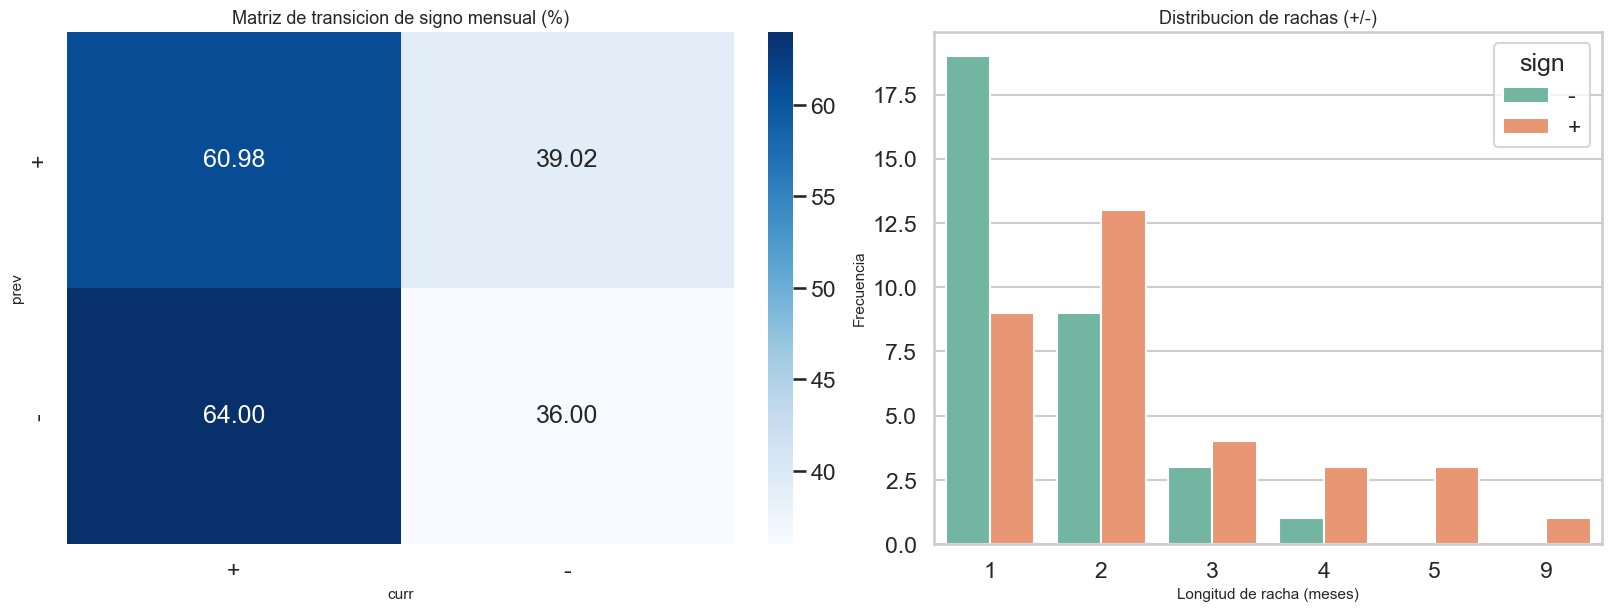

In [8]:
# Analisis de persistencia de regimenes: clasificar meses como + o -
monthly_sign = np.where(monthly_returns["strategy"] >= 0, "+", "-")
# Construir pares (signo_anterior, signo_actual) para transiciones
trans_df = pd.DataFrame(
    {"prev": pd.Series(monthly_sign).shift(1),
     "curr": monthly_sign}).dropna()
# Matriz de transicion normalizada: P(signo_t | signo_{t-1})
transition = pd.crosstab(
    trans_df["prev"],
    trans_df["curr"],
    normalize="index") * 100

# Calcular rachas: secuencias consecutivas del mismo signo
sign_series = pd.Series(monthly_sign, index=monthly_returns.index)
# Cambio de signo marca inicio de nueva racha
groups = (sign_series != sign_series.shift(1)).cumsum()
streak_df = pd.DataFrame({
    "sign": sign_series.groupby(groups).first().values,
    "length": sign_series.groupby(groups).size().values,
})

# Panel izquierdo: heatmap de la matriz de transicion (%)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# Panel derecho: histograma de longitud de rachas por signo (+/-)
sns.heatmap(transition, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de transicion de signo mensual (%)")

sns.countplot(
    data=streak_df,
    x="length",
    hue="sign",
    ax=axes[1],
    palette="Set2")
axes[1].set_title("Distribucion de rachas (+/-)")
axes[1].set_xlabel("Longitud de racha (meses)")
axes[1].set_ylabel("Frecuencia")
plt.show()


---

## 8. Riesgo dinámico

Tres paneles complementarios muestran la evolución temporal del riesgo. El **drawdown** compara la profundidad de las caídas entre estrategia y SPY: un drawdown más pronunciado implica mayor riesgo de ruina percibida. El **rolling Sharpe** (ventana de 126 días, ~6 meses) muestra si la eficiencia riesgo-retorno es estable o cíclica. El **rolling beta** mide cómo varía la exposición al mercado en el tiempo: un beta que oscila mucho sugiere que la estrategia cambia de carácter en distintos regímenes.

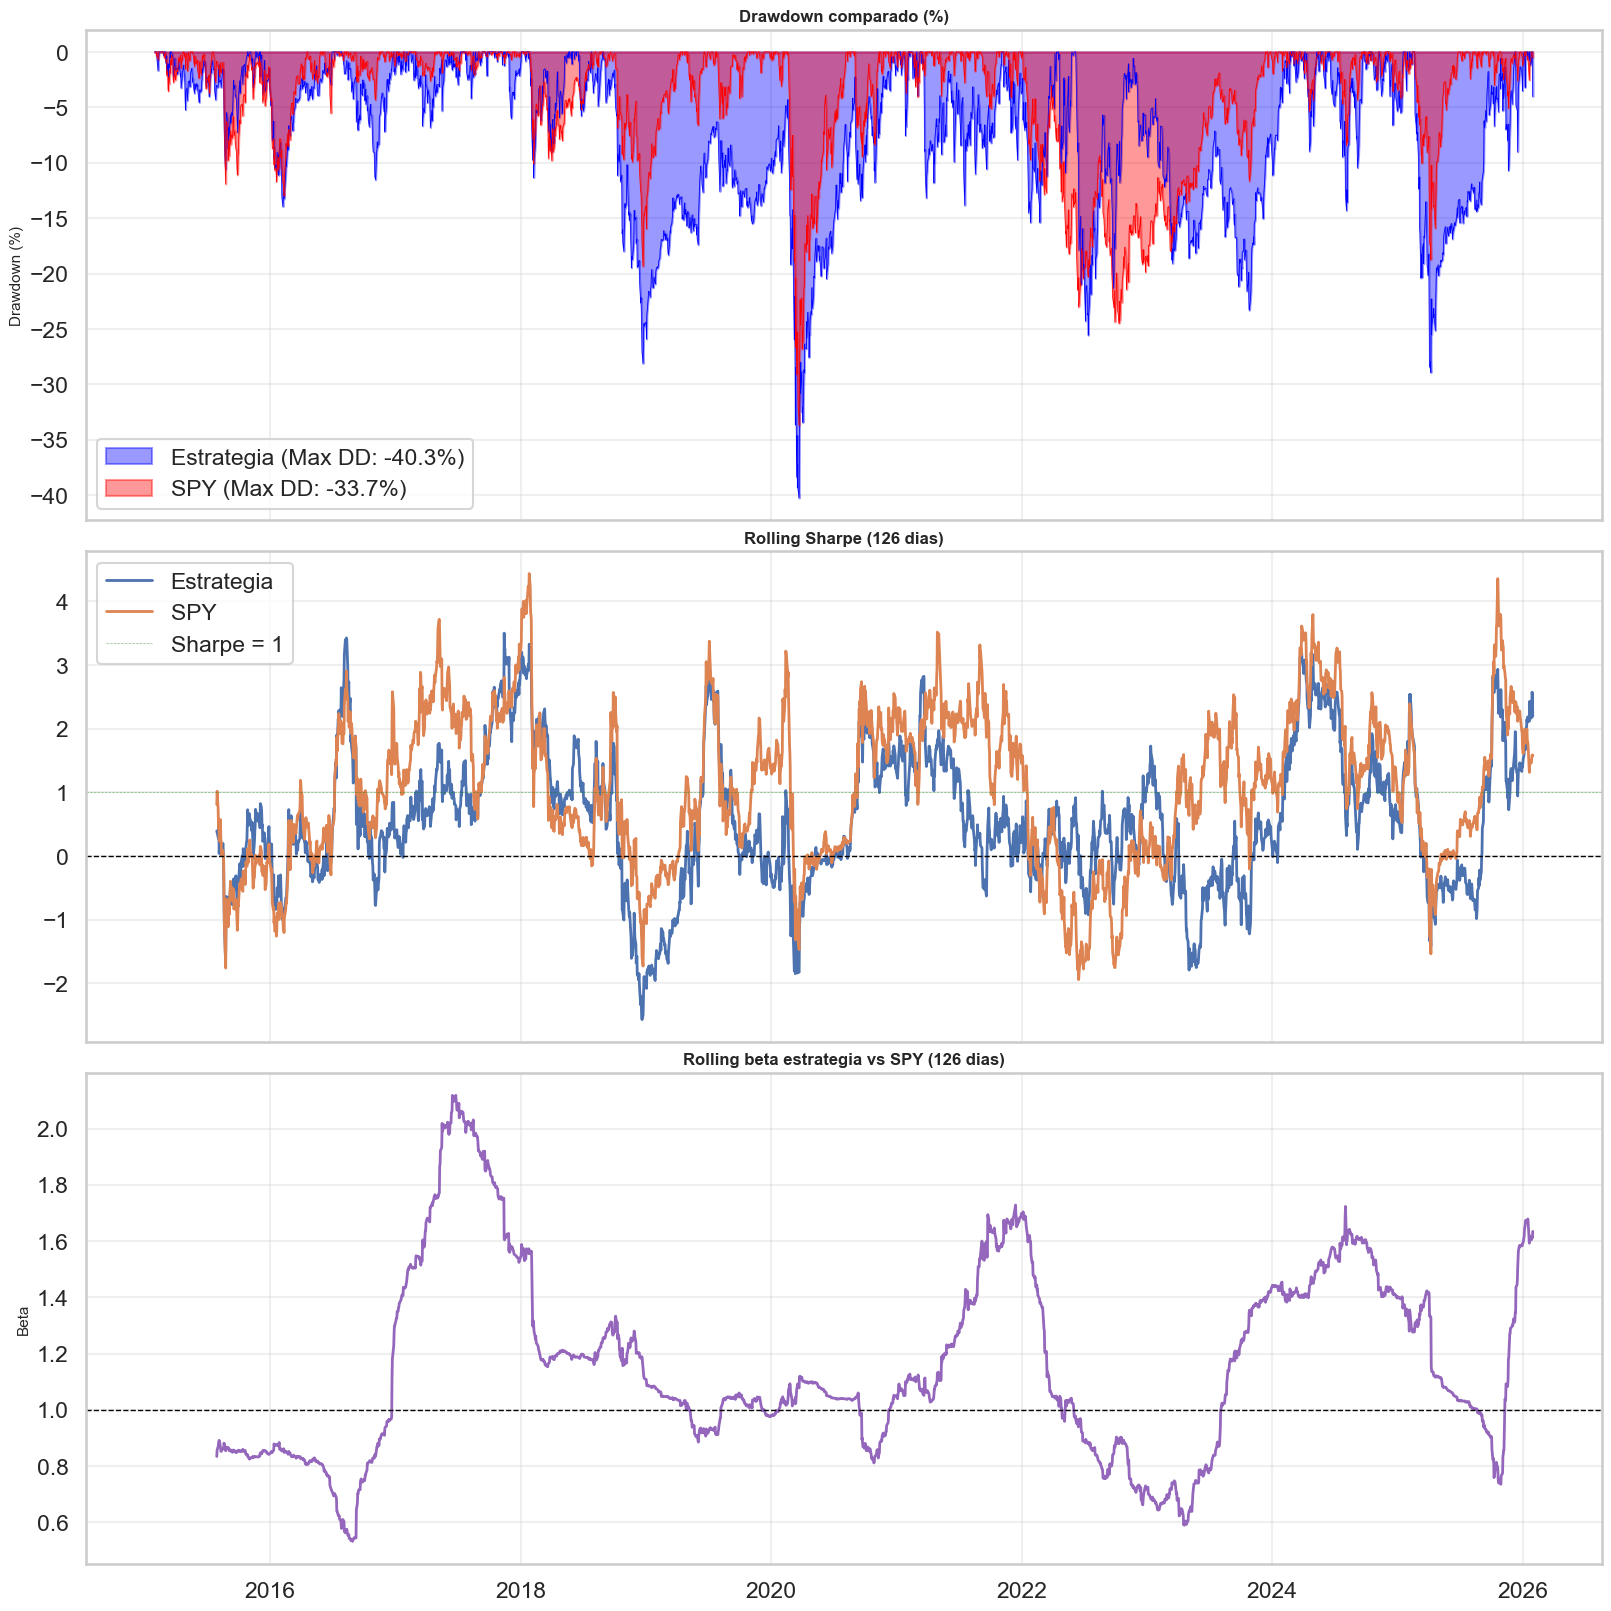

In [9]:
# Max drawdown de estrategia y SPY para anotaciones en graficos
mdd_s = float(metrics.loc[metrics["metric"] ==
              "Max Drawdown", "strategy"].iloc[0])
mdd_b = float(metrics.loc[metrics["metric"] == "Max Drawdown", "spy"].iloc[0])

# Wealth index acumulado: (1+r1)*(1+r2)*...
wealth = (1 + returns_daily[["strategy", "spy"]]).cumprod()
# Drawdown = (wealth / max_historico) - 1, siempre <= 0
dd = wealth / wealth.cummax() - 1

# Metricas rolling con ventana de 126 dias (~6 meses de mercado)
win = 126
roll_mu = returns_daily[["strategy", "spy"]].rolling(win).mean()
roll_std = returns_daily[["strategy", "spy"]].rolling(win).std(ddof=1)
# Sharpe rolling anualizado: sqrt(252) * (mu_rolling - rf) / std_rolling
roll_sharpe = np.sqrt(TRADING_DAYS) * ((roll_mu - RF_DAILY) / roll_std)

# Beta rolling: cov(strat, spy) / var(spy) sobre ventana movil de 126d
roll_beta = (
    returns_daily["strategy"].rolling(win).cov(returns_daily["spy"])
    / returns_daily["spy"].rolling(win).var()
)

# Triple panel apilado: drawdown, rolling Sharpe y rolling beta
fig, axes = plt.subplots(
    3, 1, figsize=(16, 16),
    sharex=True, constrained_layout=True)

# Panel 1: drawdown comparado (estrategia en azul, SPY en rojo)
axes[0].fill_between(
    dd.index,
    dd["strategy"] * 100,
    0,
    alpha=0.4,
    color="blue",
    label=f"Estrategia (Max DD: {
        mdd_s:.1%})")
axes[0].fill_between(dd.index, dd["spy"] * 100, 0, alpha=0.4, color="red",
                     label=f"SPY (Max DD: {mdd_b:.1%})")
# Lineas de contorno del area de drawdown
axes[0].plot(dd.index, dd["strategy"] * 100, color="blue", linewidth=0.5)
axes[0].plot(dd.index, dd["spy"] * 100, color="red", linewidth=0.5)
# Titulo y configuracion del panel de drawdown
axes[0].set_title("Drawdown comparado (%)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Drawdown (%)")
axes[0].legend(loc="lower left")
axes[0].grid(True, alpha=0.3)

# Panel 2: rolling Sharpe con referencia en 0 y en 1
# Sharpe rolling de estrategia y SPY
axes[1].plot(
    roll_sharpe.index,
    roll_sharpe["strategy"],
    label="Estrategia",
    linewidth=2)
axes[1].plot(roll_sharpe.index, roll_sharpe["spy"], label="SPY", linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    # Linea en Sharpe=1: eficiencia razonable
axes[1].axhline(
    1,
    color="green",
    linestyle="--",
    linewidth=0.5,
    alpha=0.5,
    label="Sharpe = 1")
axes[1].set_title("Rolling Sharpe (126 dias)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: rolling beta con referencia en 1 (exposicion neutral)
axes[2].plot(roll_beta.index, roll_beta, color="tab:purple", linewidth=2)
axes[2].axhline(1, color="black", linestyle="--", linewidth=1)
# Titulo y configuracion del panel de beta
axes[2].set_title(
    "Rolling beta estrategia vs SPY (126 dias)",
    fontsize=12,
    fontweight="bold")
axes[2].set_ylabel("Beta")
axes[2].grid(True, alpha=0.3)

plt.show()


---

## 9. Diagnóstico operativo y análisis de comisiones

Este bloque traduce las fricciones de ejecución a impacto económico medible. Para mejorar legibilidad, se muestran solo dos visualizaciones: **(1)** salidas forzosas con precio proxy sobre la curva de equity y **(2)** comisión total por tipo de orden con etiquetas de negocio legibles.

Además, se sustituye el detalle textual por una tabla `pandas` estilizada con métricas operativas y de comisiones: comisión total, media/mediana/mínimo/máximo por operación, impacto de la comisión mínima, incidencias `no_fill_cash` y faltantes de caja asociados.

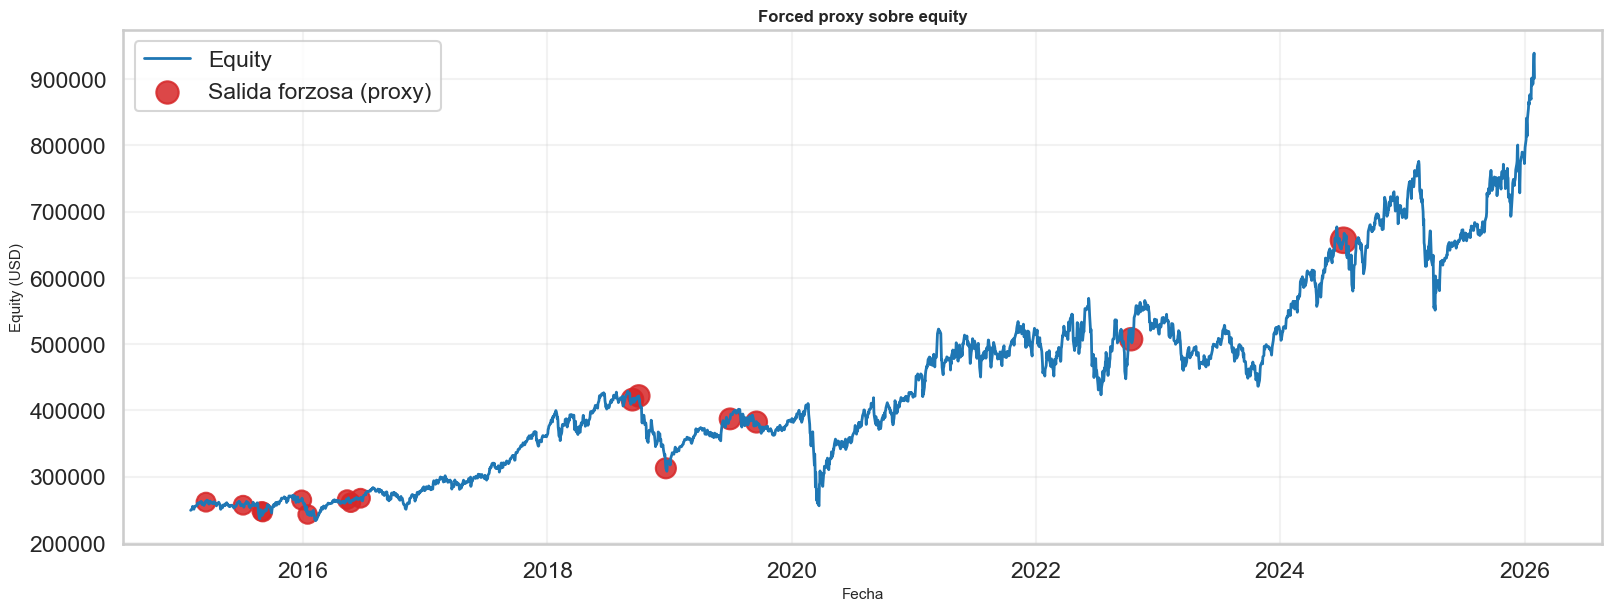

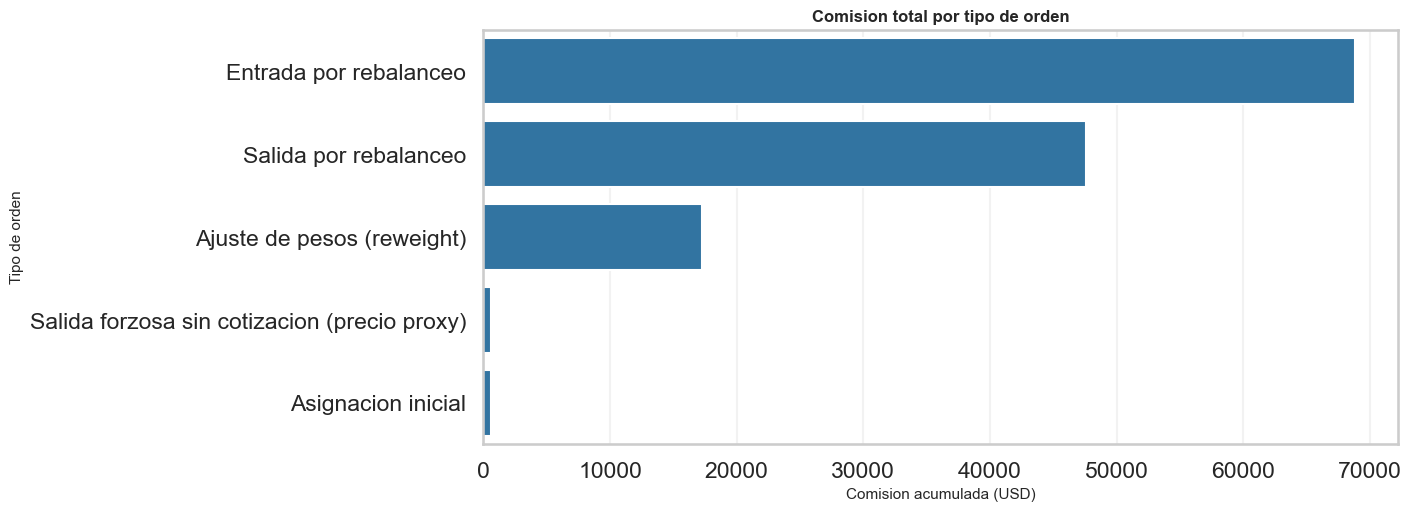

Metrica,Valor
Ordenes ejecutadas con comision,"3,594"
Comision total,"$134,828.27"
Comision / capital inicial,53.93%
Comision / equity final,14.96%
Comision media por operacion,$37.51
Comision mediana por operacion,$29.79
Comision minima por operacion,$23.00
Comision maxima por operacion,$122.05
Ordenes afectadas por comision minima,"1,632"
% de ordenes con comision minima,45.41%


In [10]:
# ================================================================
# --- Excepciones de ejecucion y costes observados ---
# Excepciones de ejecucion: ordenes rechazadas por caja insuficiente
cols_no_fill = [
    "date",
    "symbol",
    "reason",
    "price",
    "cash_before",
    "cash_after",
    "required_cash_at_close",
    "cash_gap_close"]
# Filtrar ordenes con status no_fill_cash del log de N4
# Retener solo columnas presentes en el log de ordenes
cols_no_fill = [c for c in cols_no_fill if c in orders.columns]
no_fill_cash_df = (
    orders.loc[orders["status"] == "no_fill_cash", cols_no_fill]
    .copy()
    .sort_values(["date", "symbol"])
)

# Calcular faltante de caja: required_cash - cash_disponible (clipped a 0)
if {"required_cash_at_close", "cash_before"}.issubset(no_fill_cash_df.columns):
    no_fill_cash_df["cash_shortfall"] = (
        pd.to_numeric(
            no_fill_cash_df["required_cash_at_close"],
            errors="coerce") -
        pd.to_numeric(
            no_fill_cash_df["cash_before"],
            errors="coerce")).clip(
                lower=0)
elif "cash_gap_close" in no_fill_cash_df.columns:
    no_fill_cash_df["cash_shortfall"] = pd.to_numeric(
        no_fill_cash_df["cash_gap_close"],
        errors="coerce").clip(
        lower=0)
else:
    no_fill_cash_df["cash_shortfall"] = np.nan

# Extraer salidas forzosas ejecutadas con precio proxy (last_seen_close)
forced_proxy_df = orders.loc[
    (orders["reason"] == "forced_exit_no_quote_proxy") & (orders["status"] == "filled"),
    ["date", "symbol", "price", "fee", "proxy_price_date"],
].copy().sort_values(["date", "symbol"])

# Proxy de tension mensual: estimar cuanto capital habria hecho falta
# Tabla proxy de tension mensual de caja para incidencias no_fill_cash.
# para ejecutar las posiciones rechazadas por no_fill_cash
reb = rebalance_summary.copy().sort_values("date")
if "n_rebalance_entry_no_fill_cash" not in reb.columns:
    reb["n_rebalance_entry_no_fill_cash"] = 0
# Cada posicion target = 5% equity; deficit = 5%*equity*n_no_fill - cash
reb["required_cash_proxy"] = reb["equity"] * 0.05 * reb["n_rebalance_entry_no_fill_cash"]
reb["deficit_proxy"] = np.clip(
    reb["required_cash_proxy"] - reb["cash"], 0, None)
reb_tension = reb.loc[reb["n_rebalance_entry_no_fill_cash"] > 0].copy()

# ================================================================
# --- Comisiones ---
# Analisis de comisiones sobre ordenes ejecutadas
filled = orders.loc[(orders["status"] == "filled") &
                    (orders["notional"].abs() > 0)].copy()
# Flag: True si comision proporcional (0.23% * nocional) < minimo 23 USD
filled["min_fee_hit"] = (filled["notional"].abs() * fee_rate) < fee_min
# Sobrecoste por minimo: 23 - (0.23% * nocional) para ordenes afectadas
filled["extra_min"] = np.where(
    filled["min_fee_hit"],
    fee_min -
    filled["notional"].abs() *
    fee_rate,
    0.0)

# Etiquetas legibles en espanol para tipos de orden
reason_labels = {
    "initial_allocation": "Asignacion inicial",
    "rebalance_entry": "Entrada por rebalanceo",
    "rebalance_exit": "Salida por rebalanceo",
    "rebalance_reweight": "Ajuste de pesos (reweight)",
    "forced_exit_no_quote_proxy": "Salida forzosa sin cotizacion (precio proxy)",
}

# Comision total agrupada por tipo de operacion
fee_reason = (
    filled.groupby("reason", as_index=False)["fee"]
    .sum()
    .sort_values("fee", ascending=False)
)
# Mapear codigos internos a etiquetas legibles
fee_reason["tipo_orden"] = fee_reason["reason"].map(reason_labels).fillna(
    fee_reason["reason"].str.replace("_", " ", regex=False).str.title()
)

# ================================================================
# --- Visual 1: forced proxy sobre equity ---
# Grafico 1: salidas forzosas con proxy superpuestas sobre curva de equity
fig, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
# Tamano del punto proporcional a la comision pagada en la salida
ax.plot(
    portfolio_daily["date"],
    portfolio_daily["equity"],
    color="tab:blue",
    linewidth=2,
    label="Equity")

# Mapear equity en fecha de salida forzosa para posicionar los puntos
    # Superponer puntos de salida forzosa sobre la curva de equity
if len(forced_proxy_df) > 0:
            # Agrupar por fecha y sumar comisiones de salidas proxy
    fp = forced_proxy_df.groupby(
        "date", as_index=False).agg(
        fee=("fee", "sum"))
    eq_map = portfolio_daily.set_index("date")["equity"]
    fp["equity"] = fp["date"].map(eq_map)
    fp = fp.dropna(subset=["equity"])

            # Tamano proporcional a la comision: mas grande = mas costosa
    if len(fp) > 0:
        fee_max = float(fp["fee"].max())
        if fee_max > 0:
            sizes = 80 + (fp["fee"] / fee_max) * 260
        else:
            sizes = np.full(len(fp), 120.0)
        ax.scatter(
            fp["date"],
            fp["equity"],
            color="tab:red",
            s=sizes,
            alpha=0.85,
            label="Salida forzosa (proxy)")

# Configuracion del grafico
ax.set_title("Forced proxy sobre equity", fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Equity (USD)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.25)
plt.show()

# Grafico 2: barplot horizontal de comision total por tipo de orden
# --- Visual 2: comision total por tipo de orden ---
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
sns.barplot(
    data=fee_reason,
    x="fee",
    y="tipo_orden",
    orient="h",
    ax=ax,
    color="tab:blue")
ax.set_title(
    "Comision total por tipo de orden",
    fontsize=12,
    fontweight="bold")
ax.set_xlabel("Comision acumulada (USD)")
ax.set_ylabel("Tipo de orden")
ax.grid(True, axis="x", alpha=0.25)
plt.show()

# --- Tabla de metricas operativas y de comisiones ---
# ================================================================

# Tabla consolidada de metricas operativas y de comisiones

# Funciones auxiliares de formato
def _fmt_money(x):
    return "N/A" if pd.isna(x) else f"${x:,.2f}"


def _fmt_int(x):
    return "N/A" if pd.isna(x) else f"{int(x):,}"


def _fmt_pct(x):
    return "N/A" if pd.isna(x) else f"{100 * x:.2f}%"


# Extraer valores clave para la tabla de resumen
total_fee = float(cost_summary["total_fee"].iloc[0])
init_cap = float(cost_summary["initial_capital"].iloc[0])
final_eq = float(cost_summary["final_equity"].iloc[0])

# Series de comisiones y sobrecoste por minimo para estadisticos
# Series numericas de comisiones para estadisticos
filled_fee = pd.to_numeric(filled["fee"], errors="coerce")
extra_min = pd.to_numeric(filled["extra_min"], errors="coerce")
min_hit_mask = filled["min_fee_hit"].fillna(False)

# Faltantes de caja: por orden individual y por proxy mensual
cash_shortfall = pd.to_numeric(
    no_fill_cash_df["cash_shortfall"],
    errors="coerce")
deficit_proxy = pd.to_numeric(
    reb_tension["deficit_proxy"],
    errors="coerce") if len(reb_tension) > 0 else pd.Series(
        dtype=float)

# 19 metricas operativas: comisiones, minimos, no-fills, proxies, faltantes
# Tabla consolidada: 19 filas con metricas clave de comisiones y operativa
ops_metrics = pd.DataFrame(
    [
        {"Metrica": "Ordenes ejecutadas con comision", "Valor": _fmt_int(len(filled))},
        {"Metrica": "Comision total", "Valor": _fmt_money(total_fee)},
        {"Metrica": "Comision / capital inicial", "Valor": _fmt_pct(total_fee / init_cap if init_cap > 0 else np.nan)},
        {"Metrica": "Comision / equity final", "Valor": _fmt_pct(total_fee / final_eq if final_eq > 0 else np.nan)},
        {"Metrica": "Comision media por operacion", "Valor": _fmt_money(filled_fee.mean())},
        {"Metrica": "Comision mediana por operacion", "Valor": _fmt_money(filled_fee.median())},
        {"Metrica": "Comision minima por operacion", "Valor": _fmt_money(filled_fee.min())},
        {"Metrica": "Comision maxima por operacion", "Valor": _fmt_money(filled_fee.max())},
        {"Metrica": "Ordenes afectadas por comision minima", "Valor": _fmt_int(min_hit_mask.sum())},
        {
            "Metrica": "% de ordenes con comision minima",
            "Valor": _fmt_pct(min_hit_mask.mean() if len(min_hit_mask) > 0 else np.nan),
        },
        {"Metrica": "Sobrecoste total por comision minima", "Valor": _fmt_money(extra_min.sum())},
        {
            "Metrica": "Sobrecoste medio (solo ordenes con minimo)",
            "Valor": _fmt_money(extra_min[min_hit_mask].mean() if min_hit_mask.any() else np.nan),
        },
        {"Metrica": "Ordenes no_fill_cash", "Valor": _fmt_int(len(no_fill_cash_df))},
        {
            "Metrica": "Fechas afectadas por no_fill_cash",
            "Valor": _fmt_int(no_fill_cash_df["date"].nunique() if "date" in no_fill_cash_df.columns else np.nan),
        },
        {
            "Metrica": "Faltante de caja mediano (no_fill_cash, por orden)",
            "Valor": _fmt_money(cash_shortfall.median()),
        },
        {
            "Metrica": "Faltante de caja maximo (no_fill_cash, por orden)",
            "Valor": _fmt_money(cash_shortfall.max()),
        },
        {
            "Metrica": "Faltante de caja mediano (proxy mensual)",
            "Valor": _fmt_money(deficit_proxy.median() if len(deficit_proxy) > 0 else np.nan),
        },
        {"Metrica": "Salidas forzosas con proxy", "Valor": _fmt_int(len(forced_proxy_df))},
        {
            "Metrica": "Comision total en salidas forzosas (proxy)",
            "Valor": _fmt_money(pd.to_numeric(forced_proxy_df["fee"], errors="coerce").sum() if len(forced_proxy_df) > 0 else 0.0),
        },
    ]
)

# Mostrar tabla formateada con estilo
display(
    ops_metrics.style.hide(axis="index")
    .set_caption("Resumen operativo y analisis de comisiones")
    .set_properties(subset=["Metrica", "Valor"], **{"text-align": "left"})
)


---

## 10. Monte Carlo directo (30 millones de carteras aleatorias)

### Objetivo

El test de Monte Carlo es una prueba de robustez. Su propósito es determinar si el resultado de la estrategia es estadísticamente distinguible del que se obtendría seleccionando activos al azar bajo las mismas condiciones de mercado y costes.

### Diseño metodológico

La simulación genera 30 millones de carteras aleatorias (denominadas «monos» en el enunciado) y compara su equity final con la de la estrategia real. Las decisiones de diseño son las siguientes.

El enfoque es **no paramétrico directo**: cada mono, en cada mes, selecciona 20 activos del universo elegible y recibe como retorno mensual la media aritmética de los retornos forward observados de esos 20 activos. Se utilizan retornos reales del mercado, no simulaciones a partir de una distribución asumida (como la normal o la log-normal). Esto es importante porque las distribuciones reales de retornos presentan asimetrías y colas gruesas que un modelo paramétrico subestimaría, lo cual sesgaría la comparación.

El muestreo dentro de cada mes es **sin reemplazo**: cada mono elige 20 activos distintos del universo elegible de ese mes, exactamente igual que la estrategia real. Esto replica la restricción operativa de no poder invertir dos veces en el mismo activo dentro de una misma cartera.

El coste operativo se aplica como una penalización mensual equivalente a compra y venta completas: `coste mensual = 2 × 0.23% = 0.46%`. Tal como indica el enunciado, se asume que cada mono compra y vende el 100% de su cartera en cada rebalanceo y no se aplica el mínimo de 23 USD por orden, lo cual simplifica el cálculo y permite la simulación masiva en tiempo razonable.

La ventana operativa del Monte Carlo se alinea con la del backtest real (mismo mes inicial, mismos meses de rebalanceo) para que las magnitudes sean directamente comparables.

### Métricas reportadas

Se calculan: el percentil de la estrategia dentro de la distribución de monos, la probabilidad de que un mono supere a la estrategia (`P(monkey > strategy)`), los cuantiles principales de la distribución de equity final (p01, p05, p50, p95, p99) y el tiempo total de ejecución, que debe ser inferior a 24 horas según el enunciado.

In [11]:
# Equity final y retornos de la estrategia (referencia para comparar con monos)
strategy_final_equity = float(cost_summary["final_equity"].iloc[0])
initial_capital = float(cost_summary["initial_capital"].iloc[0])
strategy_return_vs_initial_capital = float(
    cost_summary["return_vs_initial_capital"].iloc[0])
strategy_return_from_first_valuation = float(
    cost_summary["return_from_first_valuation"].iloc[0])

# ================================================================
# ================================================================
# Preparacion del universo mensual para Monte Carlo directo
# 11A. Preparacion del universo mensual para Monte Carlo directo
# Se construye la grilla de retornos forward observados por activo y mes
# ================================================================
sig_mc = signals_input[["rebalance_date", "symbol",
                        "eligible_for_signals", "close_rebalance"]].copy()
# Asegurar tipo datetime para joins temporales
sig_mc["rebalance_date"] = pd.to_datetime(sig_mc["rebalance_date"])
sig_mc = sig_mc.sort_values(
    ["symbol", "rebalance_date"]).reset_index(
    drop=True)

# Retorno forward: precio mes siguiente / precio mes actual - 1
# Retorno forward mensual por simbolo (t -> t+1)
sig_mc["close_next"] = sig_mc.groupby("symbol", observed=True)[
    "close_rebalance"].shift(-1)
sig_mc["fwd_ret"] = sig_mc["close_next"] / sig_mc["close_rebalance"] - 1

# ================================================================
# Fechas realmente operadas en N4 + fecha inicial para alinear horizonte.
# Alinear ventana MC con ventana operativa de N4
# Ojo: la primera fecha es la construccion inicial de cartera (no un
# La primera fecha es la asignacion inicial (no un rebalanceo mensual)
# rebalanceo mensual).
initial_mc_rows = portfolio_daily.loc[portfolio_daily["is_initial_allocation"], "date"]
fail_if(
    len(initial_mc_rows) == 0,
    "No se encontro fecha inicial en portfolio_daily")
initial_mc_date = pd.Timestamp(
    initial_mc_rows.drop_duplicates().sort_values().iloc[0])

signal_months = pd.Index(
    pd.concat(
        [pd.Series([initial_mc_date]),
         rebalance_summary["date"]],
        ignore_index=True).drop_duplicates().sort_values())

# Filtrar: solo activos elegibles, retorno forward finito y > -99.9%
mc_universe = sig_mc.loc[
    sig_mc["rebalance_date"].isin(signal_months)
    & (sig_mc["eligible_for_signals"])
    & np.isfinite(sig_mc["fwd_ret"])
    & (sig_mc["fwd_ret"] > -0.999),
    ["rebalance_date", "symbol", "fwd_ret"],
].copy()

# Agrupar retornos forward por mes: cada mes tiene un array de retornos
month_groups = []
# Solo meses con >= 20 activos elegibles (minimo para seleccionar k=20)
month_meta_rows = []
for dt, grp in mc_universe.groupby("rebalance_date", observed=True):
    dt = pd.Timestamp(dt)
    arr = grp["fwd_ret"].to_numpy(dtype=np.float32)
    if len(arr) >= MONKEY_K:
        month_groups.append((dt, arr))
        month_meta_rows.append(
            {"operating_date": dt, "period_type": "Construccion inicial"
             if dt == initial_mc_date else "Rebalanceo mensual",
             "n_assets": int(len(arr)),
             "mean_fwd_ret": float(arr.mean()),
             "std_fwd_ret": float(arr.std(ddof=1))
             if len(arr) > 1 else np.nan, })

# Verificar que hay meses validos para ejecutar el Monte Carlo
fail_if(len(month_groups) == 0, "No hay meses validos para Monte Carlo")

# Metadata del universo MC: n_activos, media y std por mes
month_meta_df = pd.DataFrame(month_meta_rows).sort_values(
    "operating_date").reset_index(drop=True)
mc_n_months = int(len(month_groups))
mc_month_start = month_meta_df["operating_date"].min().date()
mc_month_end = month_meta_df["operating_date"].max().date()

print("Universo Monte Carlo preparado")
print(f"  Meses validos:           {mc_n_months}")
print(
    f"  Activos/mes min-med-max: {int(month_meta_df['n_assets'].min())}-"
    f"{int(month_meta_df['n_assets'].median())}-"
    f"{int(month_meta_df['n_assets'].max())}"
)
print(f"  Monos declarados:        {N_MONKEYS:,}")
print(f"  Lotes por mes:           {int(np.ceil(N_MONKEYS / MONKEY_BATCH))}")
print(f"  Return vs capital (N4):  {strategy_return_vs_initial_capital:.2%}")
print(f"  Ventana MC (meses t):    {mc_month_start} -> {mc_month_end}")

month_meta_show = month_meta_df.rename(
    columns={
        "operating_date": "fecha_operativa",
        "period_type": "tipo_periodo",
        "n_assets": "n_activos",
        "mean_fwd_ret": "ret_forward_medio",
        "std_fwd_ret": "ret_forward_std",
    }
).copy()

display(month_meta_show.head(8))


Universo Monte Carlo preparado
  Meses validos:           132
  Activos/mes min-med-max: 459-478-484
  Monos declarados:        30,000,000
  Lotes por mes:           100
  Return vs capital (N4):  260.53%
  Ventana MC (meses t):    2015-01-30 -> 2025-12-31


,fecha_operativa,tipo_periodo,n_activos,ret_forward_medio,ret_forward_std
0,2015-01-30,Construccion inicial,480,0.057724,0.070270
1,2015-02-27,Rebalanceo mensual,481,-0.010054,0.051952
2,2015-03-31,Rebalanceo mensual,479,0.005239,0.068275
3,2015-04-30,Rebalanceo mensual,478,0.008115,0.058337
4,2015-05-29,Rebalanceo mensual,477,-0.022463,0.052128
5,2015-06-30,Rebalanceo mensual,475,0.006953,0.084175
6,2015-07-31,Rebalanceo mensual,471,-0.054000,0.058285
7,2015-08-31,Rebalanceo mensual,472,-0.031777,0.070337


In [12]:
# ================================================================
# 11B. Ejecución Monte Carlo directo (no paramétrico) por lotes
# Conversion segura de fecha para validar parametros de cache
# ================================================================
def _to_date_safe(x):
    dt = pd.to_datetime(x, errors="coerce")
    return dt.date() if pd.notna(dt) else None


# Verificar si existe ejecucion previa en cache (.npy + .csv)
cache_ready = (
    pd.io.common.file_exists(MC_DIRECT_WEALTH_NPY)
    and pd.io.common.file_exists(MC_DIRECT_SUMMARY_CSV)
)
cache_valid = False
cache_reason = ""
mc_runtime_source = "unknown"

# Si cache existe y no se fuerza recalculo, validar todos los parametros
if (not FORCE_RECOMPUTE_MONKEYS) and cache_ready:
    try:
        direct_cache = pd.read_csv(MC_DIRECT_SUMMARY_CSV)
        fail_if(direct_cache.empty, "Resumen de caché vacío")
        row = direct_cache.iloc[0]

                # Comparar cada parametro de cache con los actuales
        checks = {
            "n_monkeys": int(row.get("n_monkeys", -1)) == N_MONKEYS,
            "seed": int(row.get("seed", -1)) == MONKEY_SEED,
            "monkey_k": int(row.get("monkey_k", -1)) == MONKEY_K,
            "monkey_cost": np.isclose(
                float(row.get("monkey_cost", np.nan)),
                MONKEY_COST,
                atol=1e-12,
                rtol=0.0,
            ),
            "initial_capital": np.isclose(
                float(row.get("initial_capital", np.nan)),
                initial_capital,
                atol=1e-6,
                rtol=0.0,
            ),
            "mc_n_months": int(row.get("mc_n_months", -1)) == mc_n_months,
            "mc_month_start": _to_date_safe(row.get("mc_month_start", ""))
            == mc_month_start,
            "mc_month_end": _to_date_safe(row.get("mc_month_end", ""))
            == mc_month_end,
        }

                # Cargar vector de wealth precalculado y verificar longitud
        monkey_wealth = np.load(MC_DIRECT_WEALTH_NPY).astype(np.float32, copy=False)
        checks["wealth_len"] = len(monkey_wealth) == N_MONKEYS

                # Cache valida solo si TODOS los parametros coinciden
        cache_valid = all(checks.values())
        if cache_valid:
            direct_elapsed = float(row.get("runtime_sec", np.nan))
            mc_start = pd.to_datetime(
                row.get("mc_start_utc", ""),
                utc=True,
                errors="coerce",
            )
            mc_end = pd.to_datetime(
                row.get("mc_end_utc", ""),
                utc=True,
                errors="coerce",
            )
            rng = np.random.default_rng(MONKEY_SEED)
            mc_runtime_source = "cache_validada"
            print(
                "Monte Carlo directo cargado desde caché validada:",
                MC_DIRECT_WEALTH_NPY,
            )
        else:
            cache_reason = ", ".join([k for k, v in checks.items() if not v])

    except Exception as exc:
        cache_reason = f"error al validar caché ({exc})"

# ================================================================
if FORCE_RECOMPUTE_MONKEYS or (not cache_valid):
    # Ejecucion del Monte Carlo: 30M monos procesados por lotes
    if cache_reason:
        # Acumulacion en log-wealth: log(W) += log(1+r) para estabilidad numerica
        print(f"Caché de Monte Carlo inválida, se recomputa: {cache_reason}")

        # Generador reproducible con semilla fija
    rng = np.random.default_rng(MONKEY_SEED)
        # Vector de log-wealth acumulado para los 30M monos
    log_growth = np.zeros(N_MONKEYS, dtype=np.float32)

    mc_start = pd.Timestamp.now(tz="UTC")
    t0 = time.perf_counter()

        # Iterar mes a mes: para cada mes, todos los monos seleccionan k activos
    for m_idx, (month_dt, month_ret) in enumerate(month_groups, start=1):
        n_assets = month_ret.size
        start = 0

                # Procesar en lotes de MONKEY_BATCH para no desbordar memoria
        while start < N_MONKEYS:
            batch = min(MONKEY_BATCH, N_MONKEYS - start)
                        # Seleccion sin reemplazo: k activos distintos por mono
            idx = sample_no_replace(rng, batch, n_assets, MONKEY_K)

                        # Retorno bruto del mono = media de los k activos seleccionados
            gross = month_ret[idx].mean(axis=1, dtype=np.float32)
                        # Retorno neto: (1+r_bruto) * (1-coste) - 1
            sampled = (1.0 + gross) * (1.0 - MONKEY_COST) - 1.0
                        # Clip en -95% para evitar log(0) en la acumulacion
            sampled = np.clip(sampled, -0.95, None)

                        # Acumular en log-space: log(W) += log(1+r_neto)
            log_growth[start:start + batch] += np.log1p(sampled).astype(np.float32)
            start += batch

                # Progreso cada 12 meses con ETA estimado
        if m_idx == 1 or m_idx % 12 == 0 or m_idx == len(month_groups):
            elapsed = time.perf_counter() - t0
            eta = ((elapsed / m_idx) * (len(month_groups) - m_idx)) / 60
            print(
                f"  Mes {m_idx:03d}/{len(month_groups)} | {month_dt.date()} | "
                f"{elapsed/60:.1f} min | ETA {eta:.1f} min"
            )

        # Tiempo total de ejecucion
    direct_elapsed = time.perf_counter() - t0
    mc_end = pd.Timestamp.now(tz="UTC")

        # Convertir log-wealth a wealth: W = capital_inicial * exp(sum_log)
    monkey_wealth = (initial_capital * np.exp(log_growth.astype(np.float64))).astype(
        np.float32
    )
        # Guardar cache (.npy) para futuras ejecuciones sin recalcular
    np.save(MC_DIRECT_WEALTH_NPY, monkey_wealth)

    mc_runtime_source = "recalculado"
    print(f"\nMonte Carlo directo recalculado en {direct_elapsed/60:.1f} minutos.")
    print(f"Caché guardada en: {MC_DIRECT_WEALTH_NPY}")

# Reportar tiempo y validar requisito <24h del enunciado
runtime_min = float(direct_elapsed / 60) if np.isfinite(direct_elapsed) else np.nan
runtime_ok = bool(np.isfinite(direct_elapsed) and (direct_elapsed < 24 * 3600))
print(f"Runtime MC ({mc_runtime_source}): {runtime_min:.2f} min")
print(f"Runtime MC segundos: {direct_elapsed:.2f}")
print(f"Requisito <24h: {'PASS' if runtime_ok else 'FAIL'}")


  Mes 001/132 | 2015-01-30 | 0.6 min | ETA 79.5 min
  Mes 012/132 | 2015-12-31 | 7.0 min | ETA 70.3 min
  Mes 024/132 | 2016-12-30 | 14.1 min | ETA 63.3 min
  Mes 036/132 | 2017-12-29 | 21.1 min | ETA 56.1 min
  Mes 048/132 | 2018-12-31 | 28.0 min | ETA 49.0 min
  Mes 060/132 | 2019-12-31 | 34.9 min | ETA 41.9 min
  Mes 072/132 | 2020-12-31 | 41.9 min | ETA 34.9 min
  Mes 084/132 | 2021-12-31 | 48.8 min | ETA 27.9 min
  Mes 096/132 | 2022-12-30 | 55.7 min | ETA 20.9 min
  Mes 108/132 | 2023-12-29 | 62.7 min | ETA 13.9 min
  Mes 120/132 | 2024-12-31 | 69.5 min | ETA 7.0 min
  Mes 132/132 | 2025-12-31 | 76.4 min | ETA 0.0 min

Monte Carlo directo recalculado en 76.4 minutos.
Caché guardada en: data/processed/n5_mc_direct_wealth.npy
Runtime MC (recalculado): 76.39 min
Runtime MC segundos: 4583.56
Requisito <24h: PASS


,n_monkeys,seed,monkey_k,monkey_cost,initial_capital,mc_n_months,mc_month_start,mc_month_end,sampling,model,...,strategy_final_equity,strategy_return_vs_initial_capital,strategy_return_from_first_valuation,strategy_percentile,p_monkey_beats_strategy,p05,p50,p95,ci95_low,ci95_high
0,30000000,42,20,0.0046,250000.0,132,2015-01-30,2025-12-31,without_replacement,direct_non_parametric,...,901325.726472,2.605303,2.613472,99.986167,0.000138,316380.75,432369.125,595848.125,298093.124219,634847.251562


,q01,q05,q10,q25,q50,q75,q90,q95,q99
0,278149.25,316380.75,338862.78125,380194.0625,432369.125,492347.34375,554383.125,595848.125,684215.375


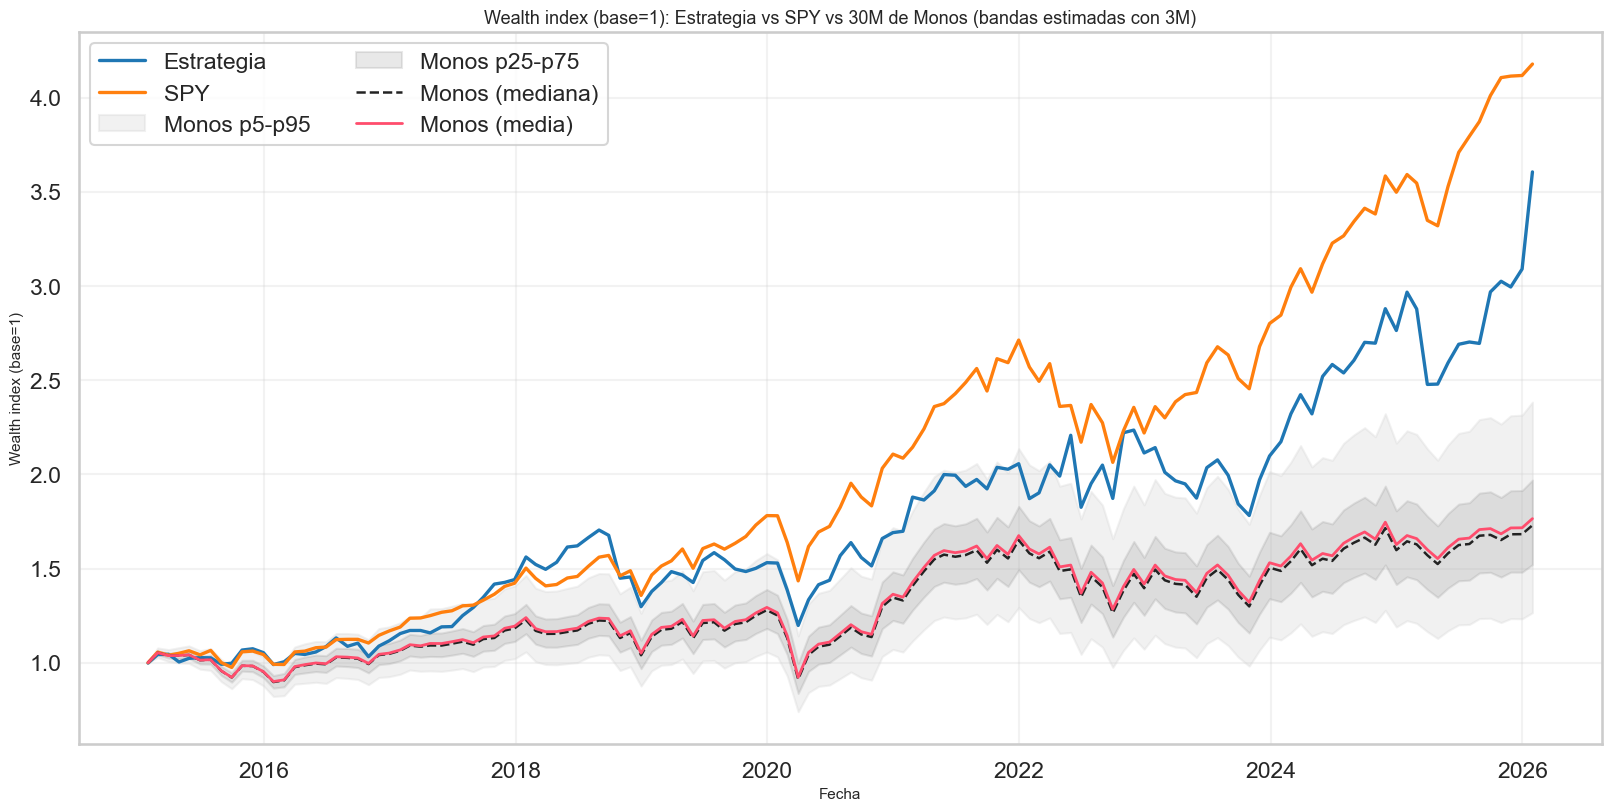

CSV directo guardados:
  data/processed/n5_mc_direct_summary.csv
  data/processed/n5_mc_direct_quantiles.csv
  data/processed/n5_mc_direct_sample.csv
  data/processed/n5_mc_direct_paths.csv (fuente: recalculado)
Requisito <24h: PASS


In [13]:
# ================================================================
# 11C. Resultados del Monte Carlo directo (bloque principal)
# ================================================================
# ================================================================
# Percentil de la estrategia dentro de la distribucion de 30M monos
p_strat = float((monkey_wealth <= strategy_final_equity).mean() * 100)
# P(monkey > strategy): probabilidad de que un mono supere la estrategia
p_monkey_beats = float((monkey_wealth > strategy_final_equity).mean())

# Cuantiles de la distribucion de equity final de los monos
p05, p50, p95 = np.percentile(monkey_wealth, [5, 50, 95])
# Intervalo de confianza al 95% [p2.5, p97.5]
ci_low, ci_high = np.percentile(monkey_wealth, [2.5, 97.5])

# DataFrame resumen con todos los parametros y resultados del MC
direct_summary_df = pd.DataFrame(
    # Se exporta como CSV para trazabilidad y reproducibilidad
    [
        {
            "n_monkeys": int(N_MONKEYS),
            "seed": int(MONKEY_SEED),
            "monkey_k": int(MONKEY_K),
            "monkey_cost": float(MONKEY_COST),
            "initial_capital": float(initial_capital),
            "mc_n_months": int(mc_n_months),
            "mc_month_start": str(mc_month_start),
            "mc_month_end": str(mc_month_end),
            "sampling": "without_replacement",
            "model": "direct_non_parametric",
            "runtime_sec": float(direct_elapsed)
            if np.isfinite(direct_elapsed)
            else np.nan,
            "runtime_min": float(direct_elapsed / 60)
            if np.isfinite(direct_elapsed)
            else np.nan,
            "runtime_lt_24h": bool(
                np.isfinite(direct_elapsed) and direct_elapsed < 24 * 3600
            ),
            "mc_start_utc": str(mc_start) if pd.notna(mc_start) else "",
            "mc_end_utc": str(mc_end) if pd.notna(mc_end) else "",
            "strategy_final_equity": float(strategy_final_equity),
            "strategy_return_vs_initial_capital": float(
                strategy_return_vs_initial_capital
            ),
            "strategy_return_from_first_valuation": float(
                strategy_return_from_first_valuation
            ),
            "strategy_percentile": float(p_strat),
            "p_monkey_beats_strategy": float(p_monkey_beats),
            "p05": float(p05),
            "p50": float(p50),
            "p95": float(p95),
            "ci95_low": float(ci_low),
            "ci95_high": float(ci_high),
        }
    ]
)

# Cuantiles de la distribucion: del percentil 1 al 99
direct_quant_df = pd.DataFrame(
    [
        {
            "q01": float(np.percentile(monkey_wealth, 1)),
            "q05": float(p05),
            "q10": float(np.percentile(monkey_wealth, 10)),
            "q25": float(np.percentile(monkey_wealth, 25)),
            "q50": float(p50),
            "q75": float(np.percentile(monkey_wealth, 75)),
            "q90": float(np.percentile(monkey_wealth, 90)),
            "q95": float(p95),
            "q99": float(np.percentile(monkey_wealth, 99)),
        }
    ]
)

# Submuestra aleatoria de 3M monos para graficos de distribucion
plot_n = min(MONKEY_PLOT_N, len(monkey_wealth))
plot_sample = monkey_wealth[rng.integers(0, len(monkey_wealth), size=plot_n)]
direct_sample_df = pd.DataFrame({"equity_final": plot_sample})

# Exportar CSVs de resultados del Monte Carlo directo
# Export CSV (directo)
# Guardar CSVs para auditoria y reproducibilidad
direct_summary_df.to_csv(MC_DIRECT_SUMMARY_CSV, index=False)
direct_quant_df.to_csv(MC_DIRECT_QUANT_CSV, index=False)
direct_sample_df.to_csv(MC_DIRECT_SAMPLE_CSV, index=False)

# Mostrar resumen y cuantiles
# Mostrar resumen del MC en pantalla
display(direct_summary_df)
# Mostrar tabla de cuantiles
display(direct_quant_df)

# ================================================================
# ---------------------------------------------------------------
# Grafico de trayectorias (wealth index base=1)
# Gráfico tipo "wealth index" para monos vs estrategia vs SPY
# Estrategia vs SPY vs bandas de percentil de 3M monos
# ---------------------------------------------------------------
# Se usa submuestra de 3M (no 30M) para calcular bandas mes a mes
# Parametros para trayectorias de monos (submuestra separada)
MC_PATHS_N = 3_000_000
MC_PATHS_BATCH = 300_000
MC_PATHS_SEED = MONKEY_SEED + 11
MC_PATHS_CSV = "data/processed/n5_mc_direct_paths.csv"

# Grid temporal: mismas fechas de senal/rebalanceo del MC
signal_months_sorted = pd.DatetimeIndex(signal_months).sort_values()
# Mapa rapido: fecha -> array de retornos forward del mes
month_ret_map = {pd.Timestamp(dt): arr for dt, arr in month_groups}

# Verificar cache de trayectorias (evitar recalcular 3M paths)
path_cache_ready = pd.io.common.file_exists(MC_PATHS_CSV)
# Estado inicial de validacion de cache
path_cache_valid = False
path_cache_reason = ""
path_source = "unknown"

# Si cache existe, validar parametros antes de usarla
    # Intentar validar cache de trayectorias antes de recalcular
if (not FORCE_RECOMPUTE_MONKEYS) and path_cache_ready:
    try:
        monkey_paths_df = pd.read_csv(MC_PATHS_CSV, parse_dates=["date"])
        required_cols = {
            "date",
            "mean",
            "median",
            "p5",
            "p25",
            "p75",
            "p95",
            "n_monkeys_paths",
            "seed_paths",
            "monkey_cost",
        }
        fail_if(
            not required_cols.issubset(monkey_paths_df.columns),
            "cache de trayectorias sin columnas requeridas",
        )
                # Verificar todos los parametros de la cache
        checks = {
            "rows": len(monkey_paths_df) == len(signal_months_sorted),
            "n_paths": int(monkey_paths_df["n_monkeys_paths"].iloc[0])
            == MC_PATHS_N,
            "seed": int(monkey_paths_df["seed_paths"].iloc[0])
            == MC_PATHS_SEED,
            "cost": np.isclose(
                float(monkey_paths_df["monkey_cost"].iloc[0]),
                MONKEY_COST,
                atol=1e-12,
                rtol=0.0,
            ),
            "dates": monkey_paths_df["date"].dt.normalize().tolist()
            == list(signal_months_sorted.normalize()),
        }
        path_cache_valid = all(checks.values())
        if path_cache_valid:
            path_source = "cache"
        else:
            path_cache_reason = ", ".join([k for k, v in checks.items() if not v])
    except Exception as exc:
        path_cache_reason = f"error de cache de trayectorias ({exc})"

# Recalcular trayectorias si no hay cache valida
if FORCE_RECOMPUTE_MONKEYS or (not path_cache_valid):
    if path_cache_reason:
        print(f"Cach? de trayectorias inválida, se recalcula: {path_cache_reason}")

        # Generador independiente (semilla diferente a la del MC principal)
            # Generador con semilla propia (diferente al MC principal)
    rng_paths = np.random.default_rng(MC_PATHS_SEED)
        # Inicializar wealth de cada mono a 1.0 (base normalizada)
            # Wealth inicial = 1.0 para cada mono (normalizado)
    wealth_paths = np.ones(MC_PATHS_N, dtype=np.float32)

            # Fila inicial: todos los monos empiezan en 1.0
    rows = [
        {
            "date": signal_months_sorted[0],
            "mean": 1.0,
            "median": 1.0,
            "p5": 1.0,
            "p25": 1.0,
            "p75": 1.0,
            "p95": 1.0,
            "n_monkeys_paths": int(MC_PATHS_N),
            "seed_paths": int(MC_PATHS_SEED),
            "monkey_cost": float(MONKEY_COST),
        }
    ]

        # Iterar mes a mes: acumular wealth *= (1 + retorno_neto)
    for idx_date, dt in enumerate(signal_months_sorted[:-1], start=1):
        month_ret = month_ret_map.get(pd.Timestamp(dt))
        fail_if(month_ret is None, f"No hay retorno forward para {dt.date()}")

        n_assets = month_ret.size
        start = 0
                # Mismo algoritmo que MC principal: lotes, sin reemplazo, con coste
        while start < MC_PATHS_N:
            batch = min(MC_PATHS_BATCH, MC_PATHS_N - start)
            picks = sample_no_replace(rng_paths, batch, n_assets, MONKEY_K)
            gross = month_ret[picks].mean(axis=1, dtype=np.float32)
            sampled = (1.0 + gross) * (1.0 - MONKEY_COST) - 1.0
            sampled = np.clip(sampled, -0.95, None)
            wealth_paths[start:start + batch] *= (1.0 + sampled).astype(np.float32)
            start += batch

                # Estadisticos de la distribucion de wealth en este mes
        p5_v, p25_v, p50_v, p75_v, p95_v = np.percentile(
            wealth_paths, [5, 25, 50, 75, 95]
        )
        rows.append(
            {
                "date": signal_months_sorted[idx_date],
                "mean": float(np.mean(wealth_paths)),
                "median": float(p50_v),
                "p5": float(p5_v),
                "p25": float(p25_v),
                "p75": float(p75_v),
                "p95": float(p95_v),
                "n_monkeys_paths": int(MC_PATHS_N),
                "seed_paths": int(MC_PATHS_SEED),
                "monkey_cost": float(MONKEY_COST),
            }
        )

        # Construir DataFrame de estadisticos por fecha y guardar cache
            # Consolidar estadisticos mensuales en DataFrame
    monkey_paths_df = pd.DataFrame(rows)
            # Guardar cache de trayectorias
    monkey_paths_df.to_csv(MC_PATHS_CSV, index=False)
    path_source = "recalculado"

# Alinear equity de la estrategia al grid de fechas MC, normalizar a base 1
strategy_eq_map = portfolio_daily.set_index("date")["equity"].sort_index()
strategy_index = (
    strategy_eq_map.reindex(signal_months_sorted).ffill().bfill() / float(initial_capital)
)

# Alinear SPY al mismo grid y normalizar a base 1
spy_px_map = spy.set_index("date")[bench_price_col].sort_index()
spy_base = spy_px_map.reindex(signal_months_sorted).ffill().bfill()
fail_if(spy_base.isna().any(), "No se pudo alinear SPY en fechas de señal MC")
spy_index = spy_base / float(spy_base.iloc[0])

# ================================================================
# Generar grafico de wealth index comparativo
fig, ax = plt.subplots(figsize=(16, 8), constrained_layout=True)
# Grafico principal: estrategia vs SPY vs bandas de monos

# Estrategia (azul), SPY (naranja), bandas p5-p95 y p25-p75
ax.plot(
    signal_months_sorted,
    strategy_index.values,
    color="#1f77b4",
    linewidth=2.4,
    label="Estrategia",
)
ax.plot(
    signal_months_sorted,
    spy_index.values,
    color="#ff7f0e",
    linewidth=2.4,
    label="SPY",
)

# Banda p5-p95: rango donde caen el 90% de los monos
ax.fill_between(
    monkey_paths_df["date"],
    monkey_paths_df["p5"],
    monkey_paths_df["p95"],
    color="lightgray",
    alpha=0.30,
    label="Monos p5-p95",
)
# Banda p25-p75: rango intercuartilico (50% central de monos)
ax.fill_between(
    monkey_paths_df["date"],
    monkey_paths_df["p25"],
    monkey_paths_df["p75"],
    color="gray",
    alpha=0.18,
    label="Monos p25-p75",
)
# Mediana de las trayectorias de monos
ax.plot(
    monkey_paths_df["date"],
    monkey_paths_df["median"],
    color="#222222",
    linestyle="--",
    linewidth=1.8,
    label="Monos (mediana)",
)
# Media de las trayectorias (puede diferir de mediana si hay asimetria)
ax.plot(
    monkey_paths_df["date"],
    monkey_paths_df["mean"],
    color="#ff4d6d",
    linewidth=2.0,
    label="Monos (media)",
)

ax.set_title(
    "Wealth index (base=1): Estrategia vs SPY vs 30M de Monos "
    "(bandas estimadas con 3M)"
)
# Configuracion de ejes y leyenda
ax.set_xlabel("Fecha")
ax.set_ylabel("Wealth index (base=1)")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", ncol=2)

plt.show()

# Resumen de ficheros exportados y validacion de requisito temporal
# Imprimir rutas de ficheros exportados
print("CSV directo guardados:")
print(f"  {MC_DIRECT_SUMMARY_CSV}")
print(f"  {MC_DIRECT_QUANT_CSV}")
print(f"  {MC_DIRECT_SAMPLE_CSV}")
print(f"  {MC_PATHS_CSV} (fuente: {path_source})")
print(
    f"Requisito <24h: {'PASS' if np.isfinite(direct_elapsed) and direct_elapsed < 24*3600 else 'FAIL'}"
)


---

## 13. Análisis crítico: respuesta a las preguntas del enunciado

### 13.1 ¿Cómo nos está afectando el sesgo de supervivencia?

El sesgo de supervivencia se produce cuando el universo de inversión utilizado en la simulación incluye únicamente activos que han sobrevivido hasta el presente, excluyendo los que quebraron, fueron adquiridos o salieron del índice durante el período de estudio. Si se incurre en este sesgo, los resultados del backtest se inflan artificialmente porque solo se consideran «ganadores».

En este proyecto, el control del sesgo de supervivencia se implementa en tres capas. En la primera, el universo de inversión se construye con composición point-in-time: para cada fecha de rebalanceo se utiliza la variable `in_sp500`, que refleja la pertenencia real al S&P 500 en esa fecha concreta, no la composición actual del índice. En la segunda, la ventana de elegibilidad exige 13 meses consecutivos de pertenencia al índice, lo que filtra activos que entran y salen rápidamente. En la tercera, cuando un activo deja de ser invertible (sale del índice o deja de cotizar), el motor de N4 ejecuta una salida forzosa al precio de cierre disponible, materializando la pérdida o ganancia en lugar de ignorar el evento.

La limitación residual es que, cuando no existe precio de cierre el día de salida, se recurre al último precio observado como proxy. Este proxy podría no reflejar el precio real de liquidación si hubo un evento adverso entre la última cotización y la salida efectiva, pero se registra con trazabilidad completa en el log de órdenes.

### 13.2 ¿Cómo hemos garantizado que no tengamos un problema de look-ahead?

El look-ahead bias se produce cuando la simulación utiliza, en algún punto de la cadena de decisiones, información que no estaba disponible en el momento real de la decisión. En una estrategia de momentum con rebalanceo mensual, los puntos de riesgo son el cálculo de la señal y la ejecución de las órdenes.

En el cálculo de la señal (N3), los retornos se construyen exclusivamente con precios laggeados: R12 utiliza los precios de cierre de los meses t-13 y t-1, y R6 los de t-7 y t-1. El mes de rebalanceo (mes t) se excluye deliberadamente para que la señal no incorpore información del período que se está decidiendo. Los z-scores se calculan con la media y la desviación del universo de ese mismo mes, sin mirar meses futuros.

En la ejecución (N4), la causalidad temporal se preserva mediante la secuencia OPEN-CLOSE: las ventas se ejecutan al OPEN del día de rebalanceo y las compras al CLOSE del mismo día. El dimensionamiento de las compras utiliza el precio OPEN como referencia, y si el CLOSE resulta más desfavorable, la orden se rechaza sin redimensionar. Redimensionar con el precio de cierre implicaría utilizar un dato que no se conoce en el momento de la decisión, lo cual constituiría un look-ahead intradía.

Los checks de N4 (`salidas_al_open`, `entradas_al_close`, `strict_open_sin_proxy_rebalance`) verifican automáticamente que esta convención temporal se respeta en todas las órdenes del backtest.

### 13.3 ¿Crees que existe un problema de overfitting?

El overfitting se produce cuando una estrategia ajusta sus parámetros sobre los datos de la muestra hasta obtener un rendimiento artificialmente bueno que no se replicará fuera de muestra. El riesgo es proporcional al número de grados de libertad ajustados y a la intensidad de la búsqueda de hiperparámetros.

En este proyecto, la estrategia implementa reglas fijas derivadas directamente del enunciado: momentum a 6 y 12 meses, normalización por z-score, selección de los 20 mejores, equiponderación al 5%. No se ha realizado ninguna búsqueda de parámetros sobre la muestra del backtest (no se han probado distintos horizontes de momentum, distintos valores de N, distintos esquemas de ponderación ni distintas frecuencias de rebalanceo para seleccionar el que mejor funciona ex post).

La robustez frente al overfitting se evalúa mediante el test de Monte Carlo de 30 millones de simulaciones. Si la estrategia estuviese sobreajustada a la muestra, su ventaja sobre el azar sería frágil y el percentil resultante no sería tan extremo. El hecho de que la estrategia se sitúe en el percentil 99,99 de la distribución aleatoria indica que la señal de momentum contiene información económica genuina que no se explica por el azar, lo cual es incompatible con un overfitting severo.

### 13.4 ¿Hemos realizado un rebalanceo irrealista?

Un rebalanceo se considera irrealista cuando asume condiciones de ejecución que no se darían en la operativa real: precios de ejecución teóricos, liquidez ilimitada, ausencia de costes, acciones fraccionales o capacidad de ejecutar simultáneamente al mismo precio de referencia.

El motor de N4 modela las principales fuentes de fricción. Las órdenes se ejecutan a precios de mercado reales (OPEN para ventas, CLOSE para compras), no a precios teóricos de cierre ajustado. Las comisiones incluyen un mínimo de 23 USD por orden, que es especialmente penalizador en órdenes pequeñas y genera un sobrecoste documentado. Solo se operan acciones enteras, lo que introduce un residuo de cash no invertido en cada rebalanceo. Cuando la caja no alcanza para completar la cartera, las posiciones que no se pueden financiar quedan vacantes y el efectivo permanece ocioso.

Las fricciones que no se modelan son el impacto de mercado (market impact) y el deslizamiento (slippage), que serían relevantes en un fondo de gran tamaño pero son despreciables para un capital de 250.000 USD operando en valores del S&P 500 con alta liquidez.

### 13.5 ¿Cuánto dinero hemos pagado en comisiones de compraventa?

La comisión total pagada durante el backtest asciende a 134.828,27 USD, lo que representa el 53,93% del capital inicial de 250.000 USD y el 14,96% de la equity final de 901.325,73 USD. Desglosada por lado, las comisiones de compra suman 69.369,70 USD y las de venta 65.458,57 USD.

Del total de 3.594 órdenes ejecutadas, 1.632 (el 45,4%) estuvieron afectadas por la comisión mínima de 23 USD, lo que significa que el 0,23% de su valor efectivo era inferior a 23 USD y se aplicó el mínimo. El sobrecoste estimado atribuible a este mínimo es de 32.586,39 USD: dinero que no se habría pagado si la comisión fuese estrictamente proporcional.

Este nivel de comisiones es coherente con la operativa descrita: 132 rebalanceos mensuales con un turnover medio del 37,8% generan un volumen significativo de órdenes, muchas de ellas de tamaño moderado (cada posición representa el 5% de un capital que oscila entre 250.000 y 900.000 USD), lo que explica que un porcentaje relevante caiga por debajo del umbral de comisión proporcional y active el mínimo de 23 USD.

## 14. Lectura ejecutiva de resultados

### Rendimiento frente al benchmark

La comparación principal se realiza en la ventana diaria común del backtest. En ese tramo, la estrategia no supera a SPY en eficiencia riesgo-retorno: su CAGR es inferior, su volatilidad es significativamente mayor, y tanto el Sharpe como el Sortino quedan por debajo del benchmark. El máximo drawdown de la estrategia es más profundo, lo que indica un mayor riesgo de pérdida pico a valle. En términos del CAPM, el resultado es coherente con un beta ligeramente superior a 1 y un alpha de Jensen anualizado negativo: la estrategia asume algo más de riesgo de mercado sin obtener una prima suficiente para compensarlo.

### Robustez frente al azar

A primera vista, la inferioridad frente a SPY podría parecer contradictoria con el resultado del Monte Carlo, donde la estrategia se sitúa en el percentil 99,99 frente a 30 millones de carteras aleatorias con costes. No hay contradicción, porque son dos preguntas distintas.

La primera pregunta es si la estrategia bate al benchmark de mercado en términos absolutos. En esta muestra, la respuesta es no: SPY captura la prima de mercado con menor fricción y menor dispersión de resultados. La segunda pregunta es si la regla de selección por momentum aporta señal real frente al azar bajo las mismas condiciones de coste. Aquí la respuesta es claramente sí: la probabilidad de que un mono supere a la estrategia es del 0,014%, lo que indica que la regla de selección contiene información económica genuina que no se explica por la suerte.

### Interpretación conjunta

La estrategia posee capacidad de discriminación demostrada frente a un baseline aleatorio, pero esa ventaja no es suficiente para superar a un ETF indexado como SPY tras costes y fricciones reales durante todo el período. Esto es un resultado frecuente en la literatura de momentum: la señal existe y es estadísticamente significativa, pero su magnitud económica neta depende críticamente del nivel de costes y de la implementación operativa.

Desde la óptica operativa, la comisión total es material: supone más de la mitad del capital inicial. El mínimo de 23 USD por orden afecta a casi la mitad de las órdenes y añade un sobrecoste relevante. Estos dos factores, junto con el cash drag de los meses con cartera incompleta, explican una parte sustancial de la brecha frente al benchmark.

### Conclusión

La estrategia es técnicamente correcta, metodológicamente robusta frente al azar y coherente con la literatura académica de momentum. Sin embargo, en esta muestra concreta y bajo estas condiciones operativas, no alcanza para batir a SPY en retorno ajustado a riesgo neto de costes. El resultado es honesto y no requiere maquillaje: demuestra que construir una señal con poder predictivo es condición necesaria pero no suficiente para generar alpha después de fricciones reales.

In [14]:
# ================================================================
# Verificación de completitud
# Cuadro resumen final: metricas clave y validaciones del enunciado
# Extraer metricas individuales para el cuadro resumen
cagr_s = float(metrics.loc[metrics["metric"] == "CAGR", "strategy"].iloc[0])
cagr_b = float(metrics.loc[metrics["metric"] == "CAGR", "spy"].iloc[0])
sharpe_s = float(metrics.loc[metrics["metric"] == "Sharpe", "strategy"].iloc[0])
maxdd_s = float(metrics.loc[metrics["metric"] == "Max Drawdown", "strategy"].iloc[0])

# Retornos de N4 para cruce con las metricas calculadas en N5
# Retornos de referencia de N4
ret_vs_initial_n4 = float(cost_summary["return_vs_initial_capital"].iloc[0])
ret_from_first_n4 = float(cost_summary["return_from_first_valuation"].iloc[0])

# Verificar que las 7 metricas obligatorias del enunciado estan presentes
required = {
    "CAGR",
    "Volatility (annualized)",
    "Sharpe",
    "Sortino",
    "Max Drawdown",
    "Beta (vs SPY)",
    "Alpha Jensen (annualized)",
}
# Completitud: todas las metricas exigidas deben estar en la tabla
present = set(metrics["metric"].tolist())
# Validar requisitos MC del enunciado: >25M monos y <24h de ejecucion
metrics_ok = required.issubset(present)
# Validar que ningun check critico de N4 haya fallado
mc_ok = bool(np.isfinite(direct_elapsed) and direct_elapsed < 24 * 3600 and N_MONKEYS >= 25_000_000)
n4_checks_ok = len(n4_critical_failed) == 0

# Impresion del cuadro resumen con todas las metricas y validaciones
print("=" * 60)
print("  NOTEBOOK 5 - RESUMEN FINAL")
print("=" * 60)
print(
    f"  Ventana:              {returns_daily.index.min().date()} -> "
    f"{returns_daily.index.max().date()}"
)
print(f"  CAGR estrategia:      {cagr_s:.4f} ({cagr_s:.2%})")
print(f"  CAGR SPY:             {cagr_b:.4f} ({cagr_b:.2%})")
print(f"  Sharpe estrategia:    {sharpe_s:.4f}")
print(f"  Max Drawdown:         {maxdd_s:.4f} ({maxdd_s:.2%})")
print(f"  Return vs capital:    {ret_vs_initial_n4:.2%}")
print(f"  Return desde val. 1:  {ret_from_first_n4:.2%}")
print(
    f"  Fee total:            ${total_fee:,.2f} "
    f"({100 * total_fee / final_eq:.1f}% equity final)"
)
print(f"  no_fill_cash:         {len(no_fill_cash_df)} órdenes")
print(f"  forced proxy exits:   {len(forced_proxy_df)} órdenes")
# Separador entre secciones del resumen
print("  ---")
print(f"  MC monos:             {N_MONKEYS:,}")
print(
    f"  MC tiempo:            {direct_elapsed / 60:.1f} min "
    f"(<24h: {'PASS' if mc_ok else 'FAIL'})"
)
print(f"  MC percentil:         {p_strat:.2f}%")
print(f"  MC P(monkey>strat):   {p_monkey_beats:.6f}")
print("  ---")
# Resumen de validaciones: PASS/FAIL para cada criterio
print(f"  Métricas completas:   {'PASS' if metrics_ok else 'FAIL'}")
print(f"  Monte Carlo válido:   {'PASS' if mc_ok else 'FAIL'}")
print(f"  Checks críticos N4:   {'PASS' if n4_checks_ok else 'FAIL'}")
print("=" * 60)


  NOTEBOOK 5 - RESUMEN FINAL
  Ventana:              2015-01-30 -> 2026-01-30
  CAGR estrategia:      0.1241 (12.41%)
  CAGR SPY:             0.1378 (13.78%)
  Sharpe estrategia:    0.5277
  Max Drawdown:         -0.4026 (-40.26%)
  Return vs capital:    260.53%
  Return desde val. 1:  261.35%
  Fee total:            $134,828.27 (15.0% equity final)
  no_fill_cash:         174 órdenes
  forced proxy exits:   16 órdenes
  ---
  MC monos:             30,000,000
  MC tiempo:            76.4 min (<24h: PASS)
  MC percentil:         99.99%
  MC P(monkey>strat):   0.000138
  ---
  Métricas completas:   PASS
  Monte Carlo válido:   PASS
  Checks críticos N4:   PASS
